In [2]:
#Nama : Ganisha Surapanno
#NIM : 825230064

In [3]:
import pandas as pd #Mengimpor Pandas, digunakan untuk manipulasi dan analisis data tabular (seperti DataFrame).
from sklearn import linear_model
import matplotlib.pyplot as plt #Mengimpor matplotlib.pyplot, pustaka utama untuk visualisasi data seperti grafik garis, batang, dll.
import seaborn as sns  #Mengimpor Seaborn, pustaka visualisasi berbasis matplotlib yang membuat grafik statistik lebih informatif dan menarik
import numpy as np #Mengimpor NumPy, pustaka untuk komputasi numerik dan manipulasi array multidimensi. 
import scipy #Mengimpor SciPy, digunakan untuk analisis statistik, optimasi, dan operasi ilmiah lainnya.
import folium #Mengimpor Folium, digunakan untuk membuat peta interaktif berbasis leaflet.js, cocok untuk visualisasi data spasial atau geografis
byw = pd.read_excel("825230064_Data Mentah.xlsx") #Membaca data dari file Excel "825230064_Data Mentah_Banyuwangi.xlsx" dan menyimpannya dalam DataFrame bernama 'byw'.

In [4]:
byw.head() #Menampilkan 5 baris pertama dari DataFrame 'byw' untuk melihat struktur dan isi data.

,Tanggal,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR
0,2010-01-01,24,34.4,28.6,79,0,4.5,5,45,1,SW
1,2010-01-02,26,33.2,29.6,74,0,8,5,360,1,N
2,2010-01-03,26,33.4,28.6,80,0,8,4,360,0,NE
3,2010-01-04,24,33.4,29.4,77,0,6.5,4,180,1,SE
4,2010-01-05,23,33.4,27.5,78,40,6.2,4,45,1,W


In [5]:
byw.tail() #Menampilkan 5 baris terakhir dari DataFrame 'byw' untuk melihat struktur dan isi data pada bagian akhir.

,Tanggal,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR
5474,2024-12-27,25.8,34.4,29.9,68,8888,2.5,6,200,3,SW
5475,2024-12-28,26.8,32.1,29.6,69,0,7,5,210,1,C
5476,2024-12-29,26.2,30.9,28.2,72,0,3.5,3,20,1,C
5477,2024-12-30,25.3,30.9,28.1,78,0.6,1.2,5,60,2,NE
5478,2024-12-31,26.1,29.9,27.9,81,0,1.5,4,50,2,SW


In [6]:
print("Jumlah missing values per kolom :")
print(byw.isnull().sum())
#Menghitung jumlah nilai yang hilang (missing values) per kolom dalam DataFrame 'byw' dan mencetak hasilnya.

Jumlah missing values per kolom :
Tanggal      0
TN         231
TX         231
TAVG       231
RH_AVG     231
RR         231
SS         231
FF_X       231
DDD_X      231
FF_AVG     231
DDD_CAR    231
dtype: int64


In [7]:
#Menampilkan jumlah baris duplikat
print("\nJumlah data duplikat :", byw.duplicated().sum())

#Menampilkan baris duplikat
print("\nBaris duplikat :")
print(byw[byw.duplicated()]) #Menampilkan baris-baris yang duplikat dalam datafram byw


Jumlah data duplikat : 0

Baris duplikat :
Empty DataFrame
Columns: [Tanggal, TN, TX, TAVG, RH_AVG, RR, SS, FF_X, DDD_X, FF_AVG, DDD_CAR]
Index: []


In [8]:
#Mengecek apakah di data ada yang 8888 atau 9999
#jika ada, nanti akan di replace dengan NaN

contains_8888 = (byw == 8888).sum().sum()
contains_9999 = (byw == 9999).sum().sum()
contains_strip = (byw == '-').sum().sum()


print(f"Jumlah nilai 8888 : {contains_8888}")
print(f"Jumlah nilai 9999 : {contains_9999}")
print(f"Jumlah nilai strip (-) : {contains_strip}")

Jumlah nilai 8888 : 272
Jumlah nilai 9999 : 1
Jumlah nilai strip (-) : 2715


In [9]:
#Menhitung persentase nilai yang hilang (Missing Values)
byw.isna().sum()/len(byw)*100

Tanggal    0.000000
TN         4.216098
TX         4.216098
TAVG       4.216098
RH_AVG     4.216098
RR         4.216098
SS         4.216098
FF_X       4.216098
DDD_X      4.216098
FF_AVG     4.216098
DDD_CAR    4.216098
dtype: float64

In [10]:
abyw = byw.copy()
#Membuat salinan DataFrame 'byw' ke dalam DataFrame baru bernama 'abyw' untuk menghindari perubahan pada data asli.
abyw.replace('-',np.nan, inplace=True) 
#Mengganti nilai strip ('-') dengan NaN (Not a Number) dalam DataFrame 'aa' untuk mengindikasikan nilai yang hilang.  
abyw.replace(8888,np.nan, inplace=True) 
#Mengganti nilai 8888 dengan NaN dalam DataFrame 'abyw' untuk mengindikasikan nilai yang hilang.
abyw.replace(9999,np.nan, inplace=True)
#Mengganti nilai 9999 dengan NaN dalam DataFrame 'abyw' untuk mengindikasikan nilai yang hilang.

C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_11192\1903377517.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  abyw.replace('-',np.nan, inplace=True)


In [11]:
abyw.describe()
#Menampilkan ringkasan statistik dari DataFrame 'abyw', termasuk count, mean, std, min, 25%, 50%, 75%, dan max untuk setiap kolom numerik.

,Tanggal,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG
count,5479,5057.000000,4965.000000,5018.000000,5017.000000,3557.000000,4943.000000,5233.000000,5235.000000,5235.000000
mean,2017-07-01 23:59:59.999999744,24.328159,31.197503,27.551096,78.930038,5.737981,6.535363,4.378177,149.528749,1.549952
min,2010-01-01 00:00:00,18.000000,23.400000,23.600000,54.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2013-10-01 12:00:00,24.000000,30.000000,26.600000,75.000000,0.000000,4.800000,3.000000,100.000000,1.000000
50%,2017-07-02 00:00:00,24.200000,31.300000,27.500000,79.000000,0.200000,7.400000,4.000000,150.000000,2.000000
75%,2021-04-01 12:00:00,25.000000,32.400000,28.500000,83.000000,5.000000,8.500000,5.000000,190.000000,2.000000
max,2024-12-31 00:00:00,28.000000,37.500000,31.700000,96.000000,127.100000,11.800000,21.000000,360.000000,6.000000
std,NaN,1.121298,1.548705,1.272921,5.678916,12.841030,2.852797,1.388338,72.607343,0.694111


In [12]:
#Mengecek apakah di data ada yang 8888 atau 9999
#jika ada, nanti akan di replace dengan NaN

acontains_8888 = (abyw == 8888).sum().sum()
acontains_9999 = (abyw == 9999).sum().sum()
acontains_strip = (abyw == '-').sum().sum()


print(f"Jumlah nilai 8888 : {acontains_8888}")
print(f"Jumlah nilai 9999 : {acontains_9999}")
print(f"Jumlah nilai strip (-) : {acontains_strip}")

Jumlah nilai 8888 : 0
Jumlah nilai 9999 : 0
Jumlah nilai strip (-) : 0


In [13]:
print("Jumlah missing values per kolom :")
print(abyw.isnull().sum())
#Menghitung persentase nilai yang hilang (Missing Values) sebelum diisi ffill bfill

Jumlah missing values per kolom :
Tanggal       0
TN          422
TX          514
TAVG        461
RH_AVG      462
RR         1922
SS          536
FF_X        246
DDD_X       244
FF_AVG      244
DDD_CAR     247
dtype: int64


In [14]:
#Mengisi missing values menggunakan metode forward fill ffill() dan backward fill bfill()
abyw = abyw.ffill()
abyw = abyw.bfill()

In [15]:
print("Jumlah missing values per kolom :")
print(abyw.isnull().sum())
#Menghitung persentase nilai yang hilang (Missing Values) setelah diisi

Jumlah missing values per kolom :
Tanggal    0
TN         0
TX         0
TAVG       0
RH_AVG     0
RR         0
SS         0
FF_X       0
DDD_X      0
FF_AVG     0
DDD_CAR    0
dtype: int64


In [16]:
abyw.to_excel('825230064_Data Bersih.xlsx',index = False)
#Menyimpan DataFrame 'abyw' yang telah dibersihkan ke dalam file Excel baru bernama "825230064_Data Bersih.xlsx" tanpa menyertakan indeks.

In [17]:
#mencetak nama kolom
nama_kolom = abyw.columns
nama_kolom

Index(['Tanggal', 'TN', 'TX', 'TAVG', 'RH_AVG', 'RR', 'SS', 'FF_X', 'DDD_X',
       'FF_AVG', 'DDD_CAR'],
      dtype='object')

In [18]:
#Menambahkan kolom Tahun, Bulan dan Hari pada data frame yang diekstrasi dari kolon Tanggal
abyw['Tahun'] = pd.DatetimeIndex(abyw['Tanggal']).year
abyw['Bulan'] = pd.DatetimeIndex(abyw['Tanggal']).month
abyw['Hari'] = abyw['Tanggal'].dt.day_name()

In [19]:
abyw.head()

,Tanggal,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR,Tahun,Bulan,Hari
0,2010-01-01,24.0,34.4,28.6,79.0,0.0,4.5,5.0,45.0,1.0,SW,2010,1,Friday
1,2010-01-02,26.0,33.2,29.6,74.0,0.0,8.0,5.0,360.0,1.0,N,2010,1,Saturday
2,2010-01-03,26.0,33.4,28.6,80.0,0.0,8.0,4.0,360.0,0.0,NE,2010,1,Sunday
3,2010-01-04,24.0,33.4,29.4,77.0,0.0,6.5,4.0,180.0,1.0,SE,2010,1,Monday
4,2010-01-05,23.0,33.4,27.5,78.0,40.0,6.2,4.0,45.0,1.0,W,2010,1,Tuesday


In [20]:
bbyw = abyw.copy()
#Membuat salinan DataFrame 'abyw' ke dalam DataFrame baru bernama 'bbyw' untuk menghindari perubahan pada data asli.

In [21]:
bbyw.head()
#Menampilkan 5 baris pertama dari DataFrame 'bbyw' untuk melihat struktur dan isi data setelah pembersihan.

,Tanggal,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR,Tahun,Bulan,Hari
0,2010-01-01,24.0,34.4,28.6,79.0,0.0,4.5,5.0,45.0,1.0,SW,2010,1,Friday
1,2010-01-02,26.0,33.2,29.6,74.0,0.0,8.0,5.0,360.0,1.0,N,2010,1,Saturday
2,2010-01-03,26.0,33.4,28.6,80.0,0.0,8.0,4.0,360.0,0.0,NE,2010,1,Sunday
3,2010-01-04,24.0,33.4,29.4,77.0,0.0,6.5,4.0,180.0,1.0,SE,2010,1,Monday
4,2010-01-05,23.0,33.4,27.5,78.0,40.0,6.2,4.0,45.0,1.0,W,2010,1,Tuesday


In [22]:
#Mempersiapkan data untuk menghitung nilai koreasi antar variabel polutan
bbyw = bbyw.drop(['Tanggal', 'DDD_CAR','Tahun','Bulan','Hari'],axis = 1)

bbyw.head()

,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG
0,24.0,34.4,28.6,79.0,0.0,4.5,5.0,45.0,1.0
1,26.0,33.2,29.6,74.0,0.0,8.0,5.0,360.0,1.0
2,26.0,33.4,28.6,80.0,0.0,8.0,4.0,360.0,0.0
3,24.0,33.4,29.4,77.0,0.0,6.5,4.0,180.0,1.0
4,23.0,33.4,27.5,78.0,40.0,6.2,4.0,45.0,1.0


In [23]:
c = bbyw.corr()
# Menghitung korelasi antar kolom (dalam hal ini antar polutan) pada dataframe ispu3.
# Metode .corr() secara default menggunakan korelasi Pearson.

c
# Menampilkan matriks korelasi yang telah dihitung dan disimpan dalam variabel c.


,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG
TN,1.000000,0.445075,0.580117,-0.037317,-0.116386,0.053786,0.050651,-0.078247,-0.020527
TX,0.445075,1.000000,0.797648,-0.368674,-0.035503,0.133968,0.064948,-0.119017,-0.022323
TAVG,0.580117,0.797648,1.000000,-0.528478,-0.108021,0.256627,0.080204,-0.190340,0.013258
RH_AVG,-0.037317,-0.368674,-0.528478,1.000000,0.260660,-0.514795,-0.110970,0.066697,-0.157283
RR,-0.116386,-0.035503,-0.108021,0.260660,1.000000,-0.204692,-0.014333,-0.055456,-0.132877
SS,0.053786,0.133968,0.256627,-0.514795,-0.204692,1.000000,0.045316,-0.059368,0.132028
FF_X,0.050651,0.064948,0.080204,-0.110970,-0.014333,0.045316,1.000000,-0.103453,0.475988
DDD_X,-0.078247,-0.119017,-0.190340,0.066697,-0.055456,-0.059368,-0.103453,1.000000,0.117356
FF_AVG,-0.020527,-0.022323,0.013258,-0.157283,-0.132877,0.132028,0.475988,0.117356,1.000000


In [24]:
colors = ['blue', 'darkblue', 'lightblue', 'deepskyblue', 'red',
          'green', 'purple', 'orange', 'darkred', 'chocolate', 'gold',
          'darkgreen', 'cadetblue', 'darkviolet', 'pink', 'lightgreen',
          'teal', 'mediumpurple', 'springgreen', 'lightcoral', 'olivedrab',
          'olive', 'turquoise', 'lightseagreen', 'magenta', 'khaki', 'springgreen',
          'hotpink', 'black']
#List warna-warna dasar dalam string

C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_11192\2021540140.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rho = c.iloc[x][y]                                    # Mengambil nilai korelasi dari DataFrame 'c' pada posisi x, y


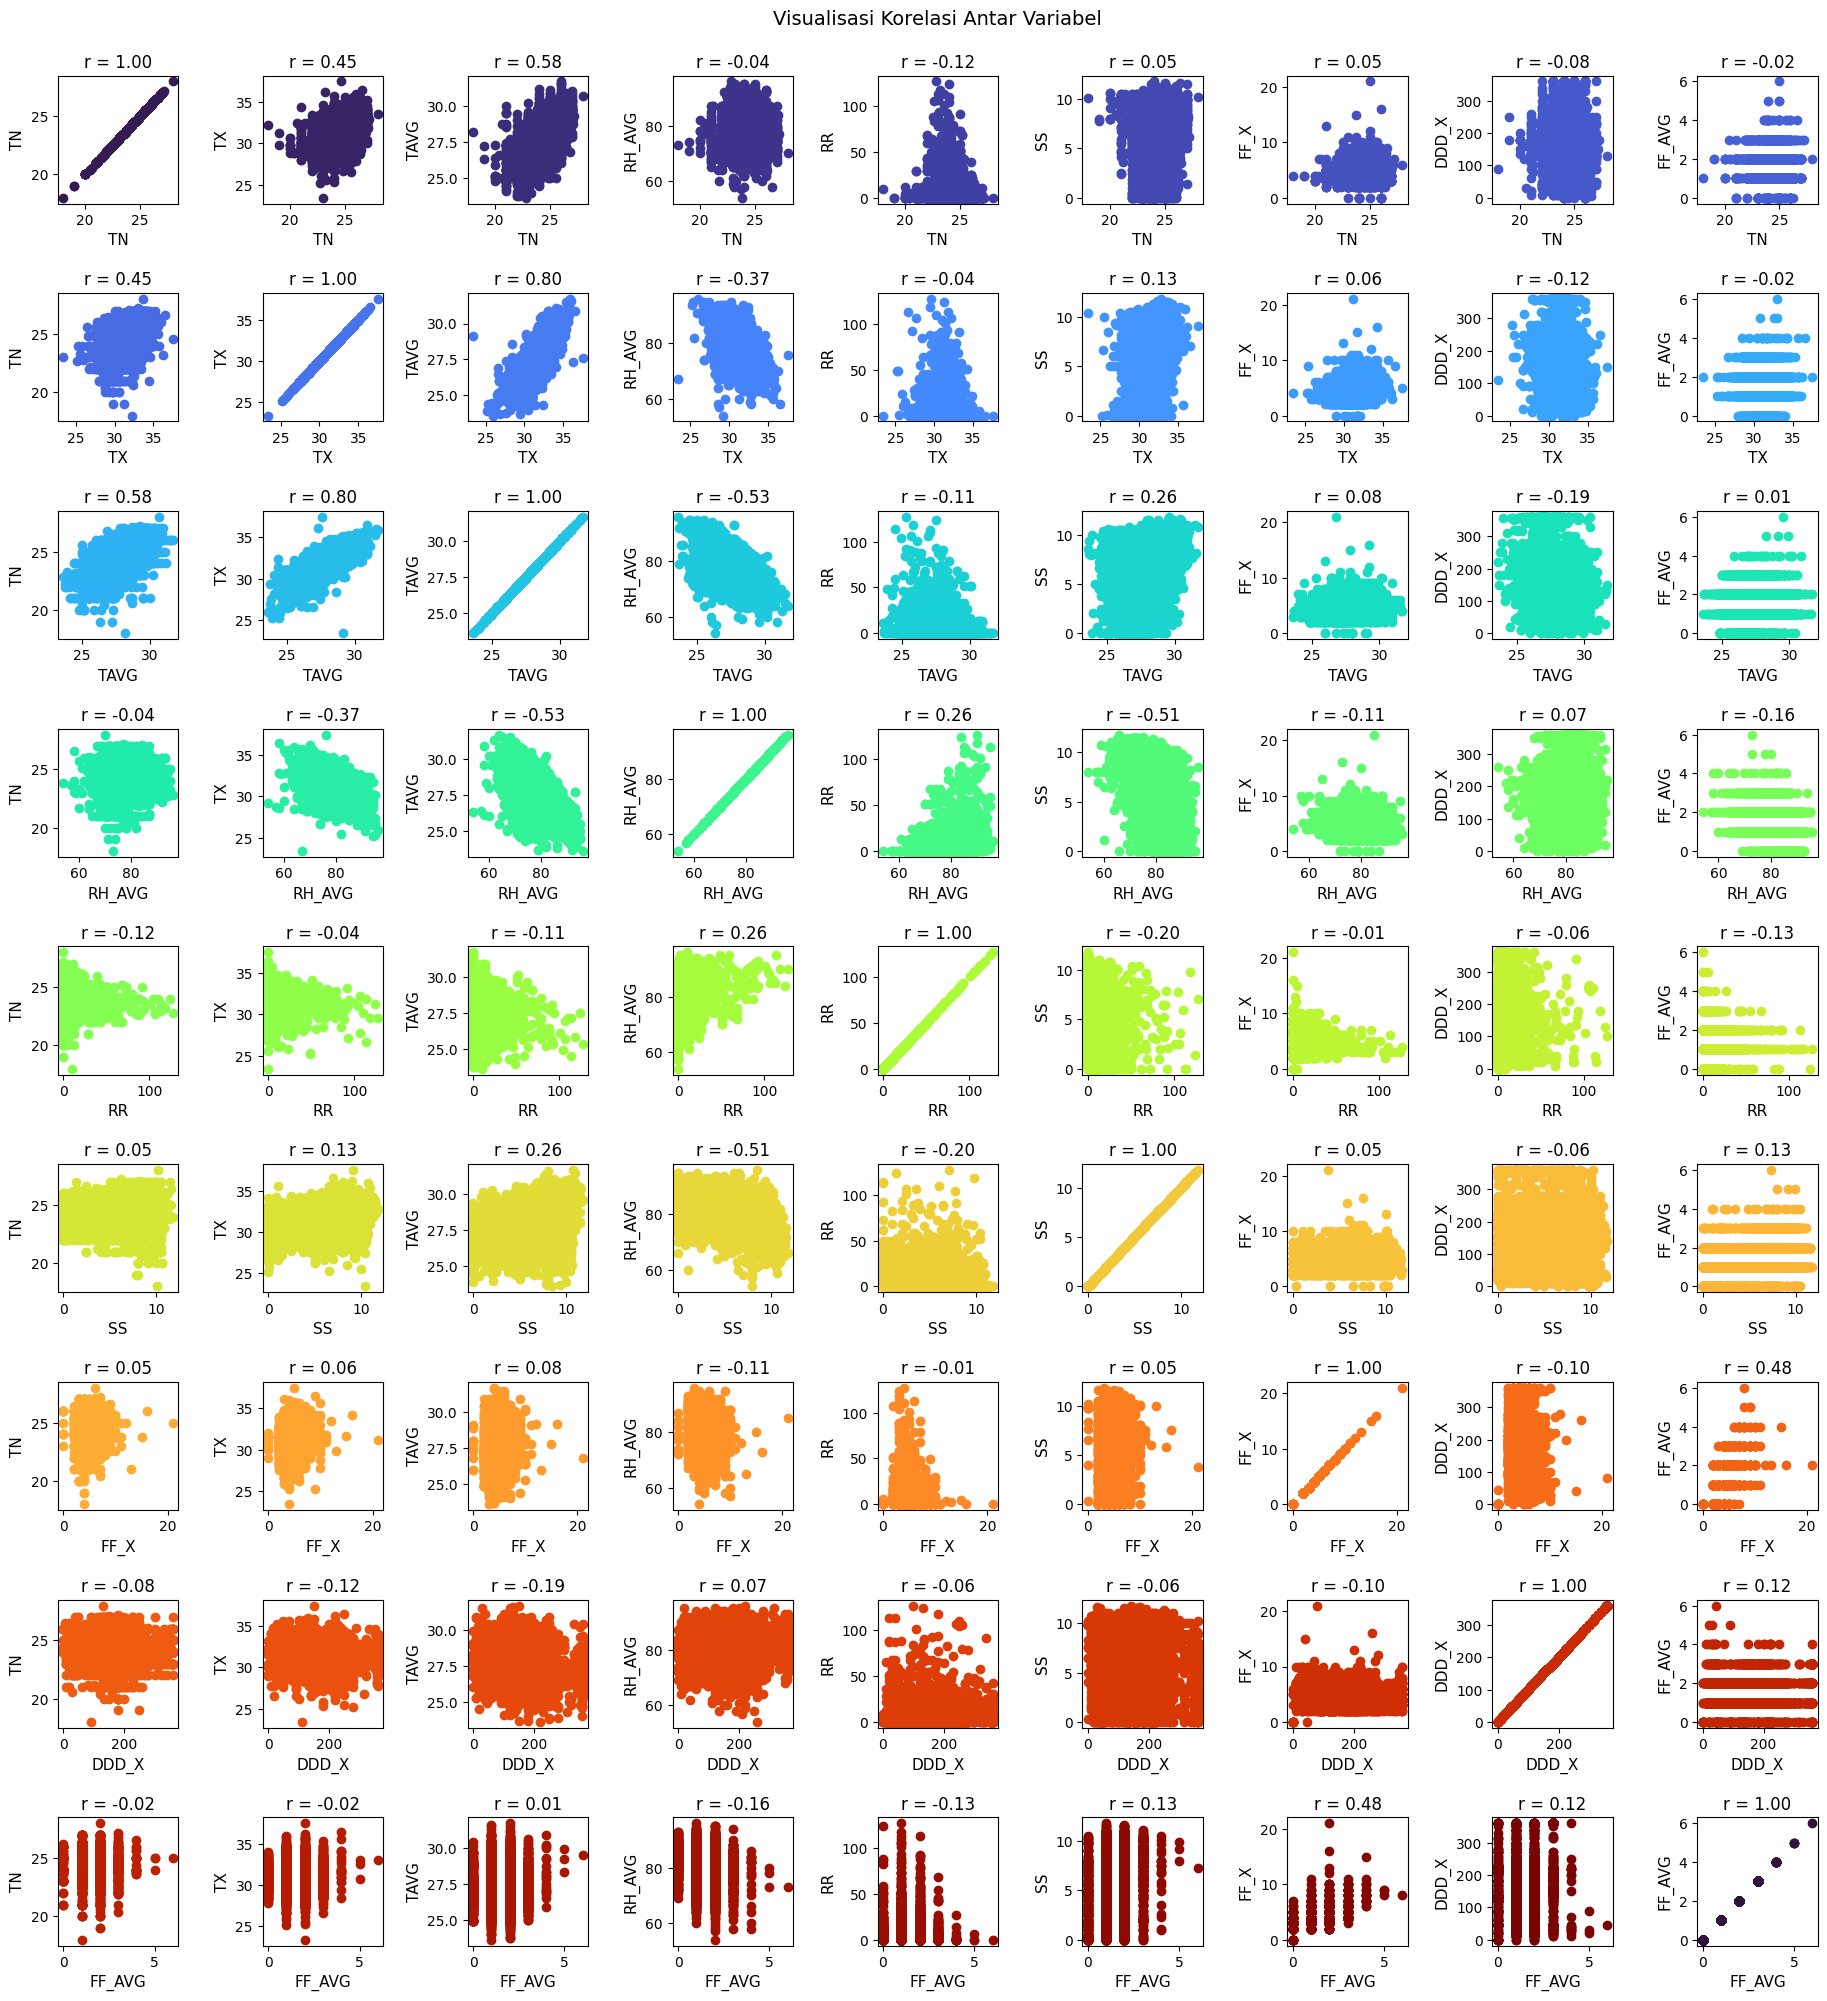

In [38]:
fig = plt.subplots(9, 9, figsize=(22, 22))                 # Membuat grid subplot 9x9 dengan ukuran gambar 22x22 inci
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.95, 
                    wspace=0.7, hspace=0.7)                    # Menyesuaikan jarak antar subplot
col = c.columns            
n = len(col)                                    # Menyimpan nama-nama kolom dari DataFrame 'c'
k = 1
x = 0
colors = plt.cm.turbo(np.linspace(0, 1, n * n)) # Membuat palet warna menggunakan colormap 'turbo' dari matplotlib

for i in col:                                                 # Looping untuk setiap kolom sebagai variabel x
    y = 0
    for j in col:                                             # Looping untuk setiap kolom sebagai variabel y
        plt.subplot(9, 9, k)                                  # Membuat subplot ke-k dari total 81
        plt.scatter(abyw[i], abyw[j], color=colors[k % len(colors)])      # Membuat scatter plot antar variabel i dan j dengan warna tertentu
        rho = c.iloc[x][y]                                    # Mengambil nilai korelasi dari DataFrame 'c' pada posisi x, y
        plt.title('r = ' + f'{rho:.2f}')                      # Menampilkan nilai korelasi pada judul plot
        plt.xlabel(i, fontsize=11)                                         
        plt.ylabel(j, fontsize=11)                                         
        k = k + 1
        y = y + 1
    x = x + 1

plt.suptitle("Visualisasi Korelasi Antar Variabel", fontsize=14)           
plt.show()                                                    

#Kode ini membuat visualisasi scatter plot 9×9 untuk menunjukkan hubungan antar semua pasangan variabel numerik dalam DataFrame abyw, lengkap dengan nilai korelasi Pearson di setiap plot

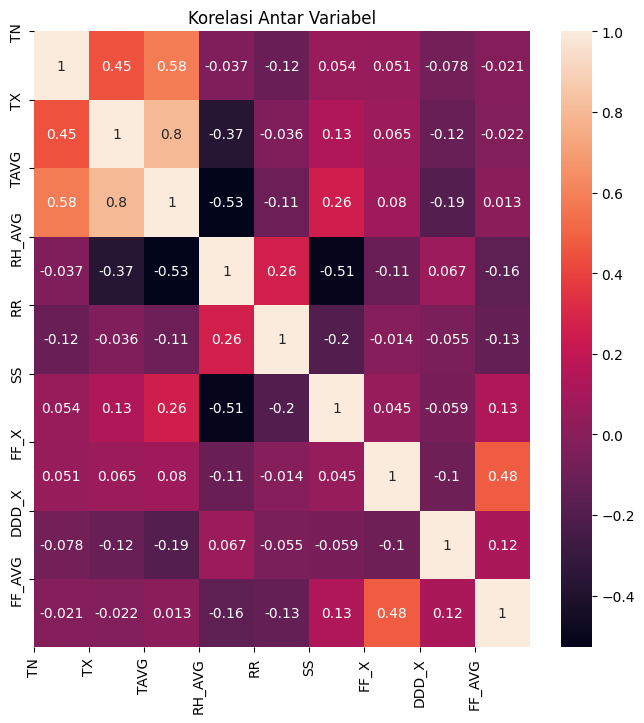

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
hm = sns.heatmap(data=c,annot=True)
plt.title("Korelasi Antar Variabel")
plt.xticks(range(len(c.columns)),c.columns, rotation=90)
plt.yticks(range(len(c.columns)), c.columns)
plt.show()

#membuat heatmap (peta panas) korelasi antar variabel menggunakan Seaborn, berdasarkan DataFrame c yang berisi nilai korelasi antar kolom numerik

C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_21424\2241029362.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  text = ax.text(j, i, '%.3f' % c.iloc[i][j],


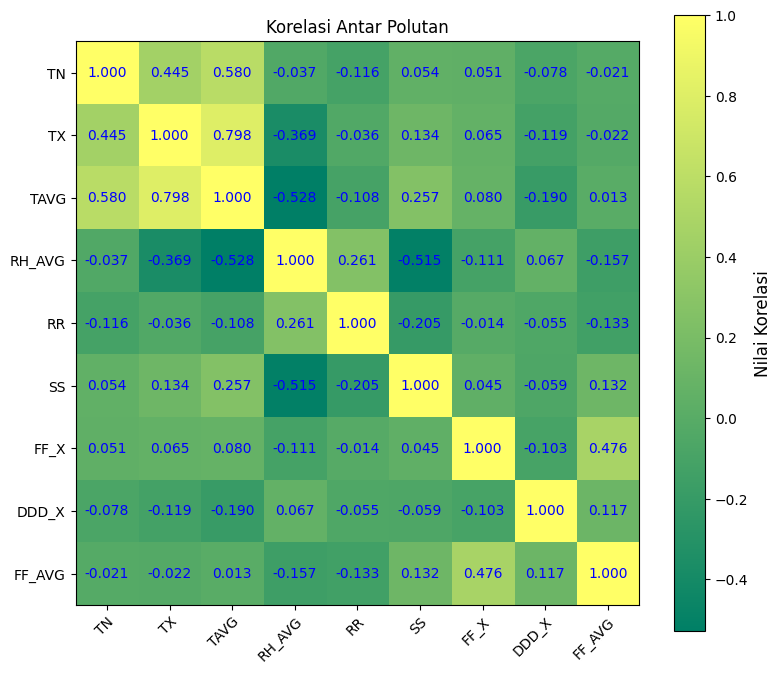

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(c, cmap = 'summer')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Nilai Korelasi', fontsize=12)

plt.xticks(range(len(c.columns)),c.columns, rotation=90)
plt.yticks(range(len(c.columns)), c.columns)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(len(c)) :
    for j in range(len(c)):
        text = ax.text(j, i, '%.3f' % c.iloc[i][j],
                       ha="center", va="center", color="b")
        
ax.set_title("Korelasi Antar Polutan")
fig.tight_layout()
plt.show()

#membuat heatmap korelasi antar polutan berdasarkan DataFrame c (hasil .corr()), untuk menunjukkan seberapa kuat hubungan antar jenis indikator iklim

C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_11192\4268568276.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=abyw, x='Tahun', y='TN', palette='RdYlGn')
C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_11192\4268568276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=abyw, x='Tahun', y='TX', palette='RdYlGn')
C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_11192\4268568276.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=abyw, x='Tahun', y='TAVG', palette='RdYlGn')
C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_1

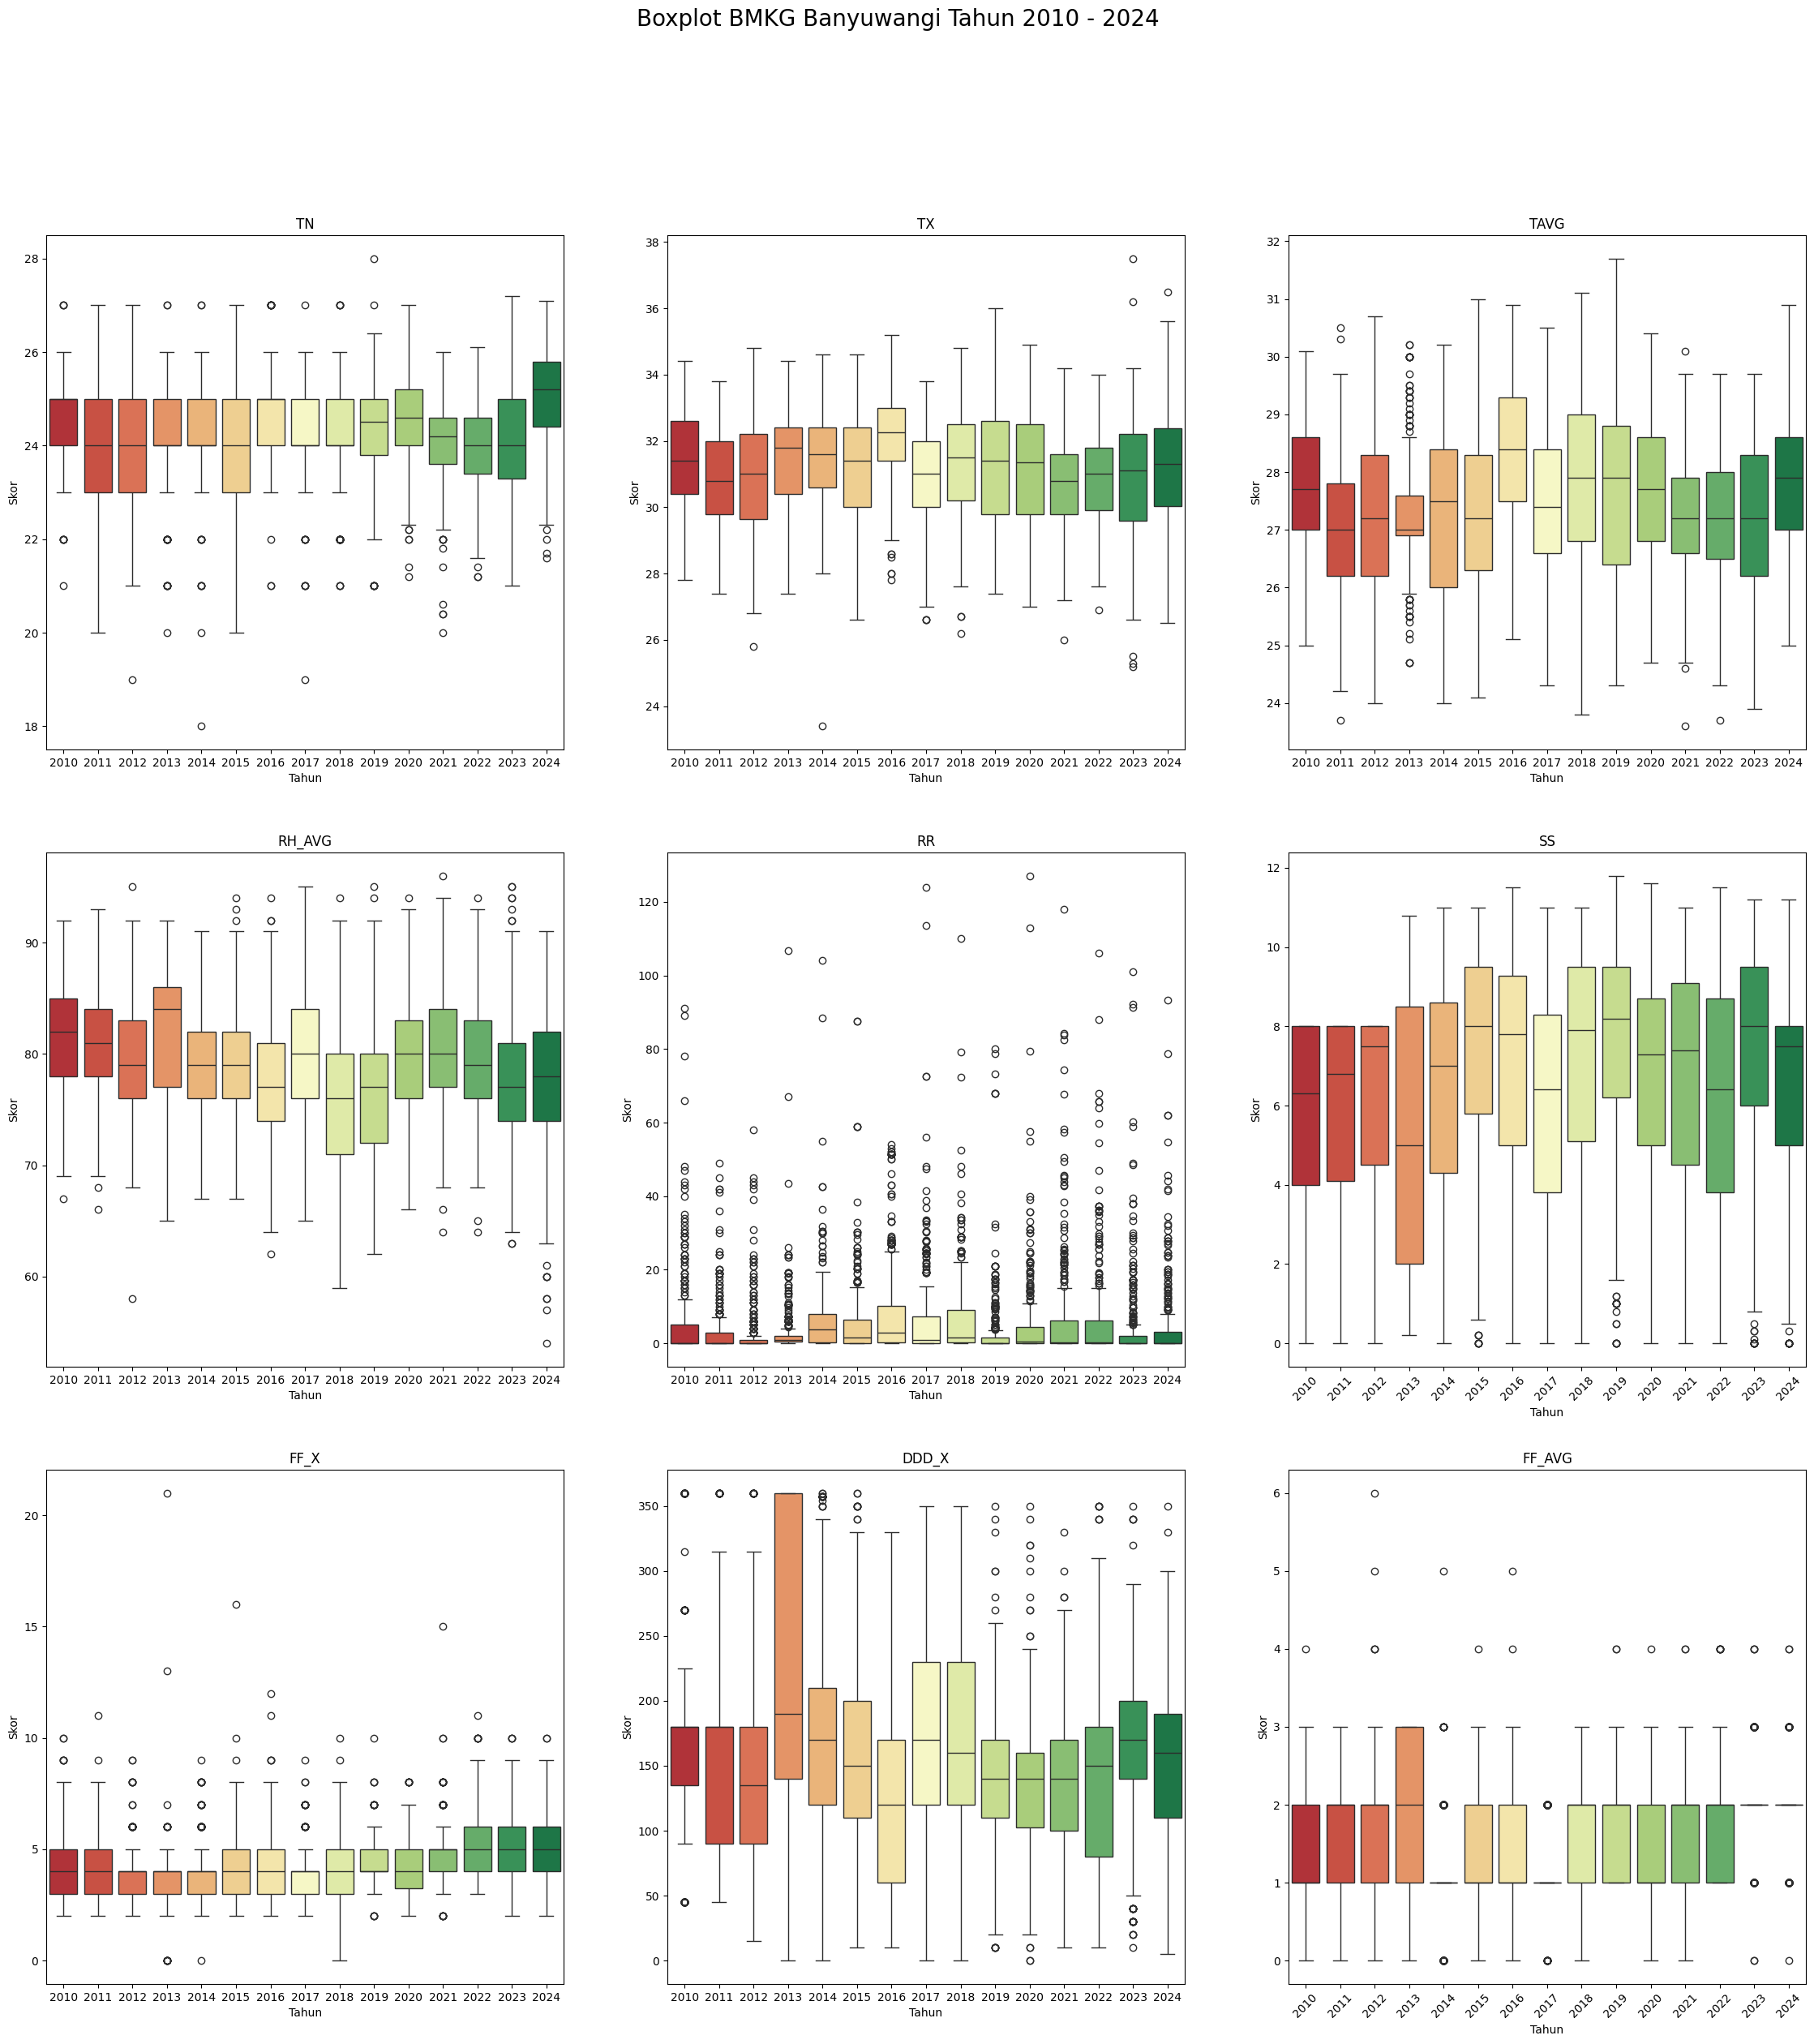

In [32]:
fig = plt.subplots(3, 3, figsize=(28,28))
plt.subplot(3, 3, 1)
sns.boxplot(data=abyw, x='Tahun', y='TN', palette='RdYlGn')
plt.title('TN')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 2)
sns.boxplot(data=abyw, x='Tahun', y='TX', palette='RdYlGn')
plt.title('TX')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 3)
sns.boxplot(data=abyw, x='Tahun', y='TAVG', palette='RdYlGn')
plt.title('TAVG')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 4)
sns.boxplot(data=abyw, x='Tahun', y='RH_AVG', palette='RdYlGn')
plt.title('RH_AVG')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 5)
sns.boxplot(data=abyw, x='Tahun', y='RR', palette='RdYlGn')
plt.title('RR')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 6)
sns.boxplot(data=abyw, x='Tahun', y='SS', palette='RdYlGn')
plt.title('SS')
plt.ylabel('Skor')
plt.xlabel('Tahun')
plt.xticks(rotation=45)

plt.subplot(3, 3, 7)
sns.boxplot(data=abyw, x='Tahun', y='FF_X', palette='RdYlGn')
plt.title('FF_X')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 8)
sns.boxplot(data=abyw, x='Tahun', y='DDD_X', palette='RdYlGn')
plt.title('DDD_X')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 9)
sns.boxplot(data=abyw, x='Tahun', y='FF_AVG', palette='RdYlGn')
plt.title('FF_AVG')
plt.ylabel('Skor')
plt.xlabel('Tahun')
plt.xticks(rotation=45)

plt.suptitle("Boxplot BMKG Banyuwangi Tahun 2010 - 2024", fontsize=20)
plt.show()
#membuat boxplot untuk setiap variabel polutan berdasarkan tahun, untuk melihat distribusi indikator iklim dari tahun ke tahun

C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_11192\728499790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=abyw, x='Bulan', y='TN', palette='RdYlGn')
C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_11192\728499790.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=abyw, x='Bulan', y='TX', palette='RdYlGn')
C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_11192\728499790.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=abyw, x='Bulan', y='TAVG', palette='RdYlGn')
C:\Users\Ganisha S\AppData\Local\Temp\ipykernel_1119

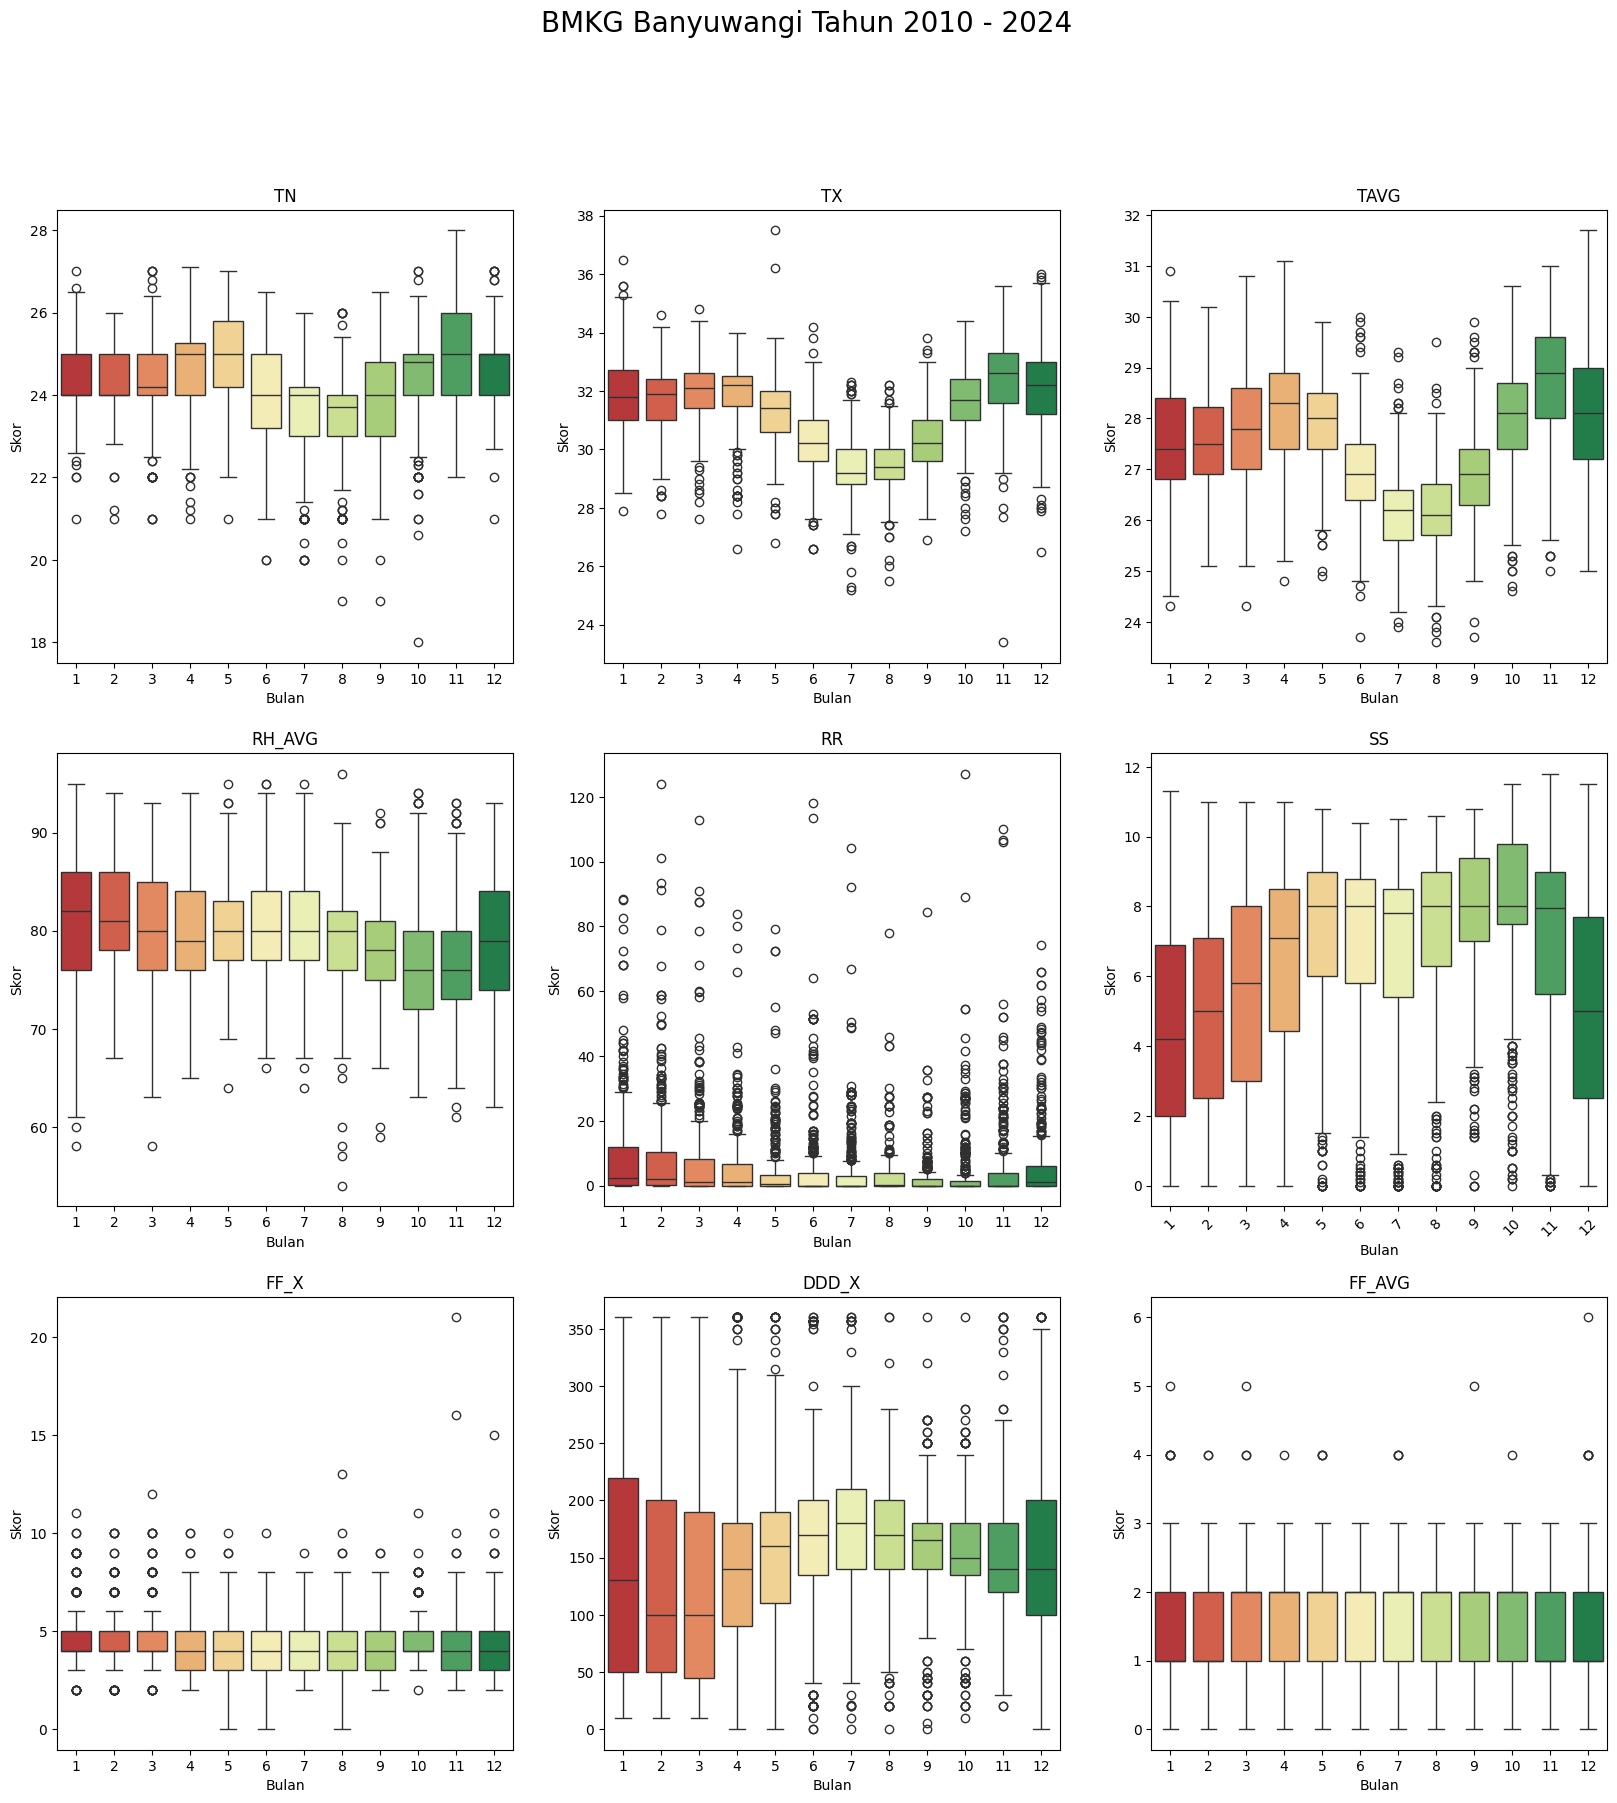

In [27]:
fig = plt.subplots(3, 3, figsize=(20,20))
plt.subplot(3, 3, 1)
sns.boxplot(data=abyw, x='Bulan', y='TN', palette='RdYlGn')
plt.title('TN')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 2)
sns.boxplot(data=abyw, x='Bulan', y='TX', palette='RdYlGn')
plt.title('TX')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 3)
sns.boxplot(data=abyw, x='Bulan', y='TAVG', palette='RdYlGn')
plt.title('TAVG')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 4)
sns.boxplot(data=abyw, x='Bulan', y='RH_AVG', palette='RdYlGn')
plt.title('RH_AVG')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 5)
sns.boxplot(data=abyw, x='Bulan', y='RR', palette='RdYlGn')
plt.title('RR')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 6)
sns.boxplot(data=abyw, x='Bulan', y='SS', palette='RdYlGn')
plt.title('SS')
plt.ylabel('Skor')
plt.xlabel('Bulan')
plt.xticks(rotation=45)

plt.subplot(3, 3, 7)
sns.boxplot(data=abyw, x='Bulan', y='FF_X', palette='RdYlGn')
plt.title('FF_X')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 8)
sns.boxplot(data=abyw, x='Bulan', y='DDD_X', palette='RdYlGn')
plt.title('DDD_X')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 9)
sns.boxplot(data=abyw, x='Bulan', y='FF_AVG', palette='RdYlGn')
plt.title('FF_AVG')
plt.ylabel('Skor')

plt.suptitle("BMKG Banyuwangi Tahun 2010 - 2024",fontsize=20)
plt.show()
#membuat boxplot untuk setiap variabel polutan berdasarkan bulan, untuk melihat distribusi indikator iklim dari bulan ke bulan

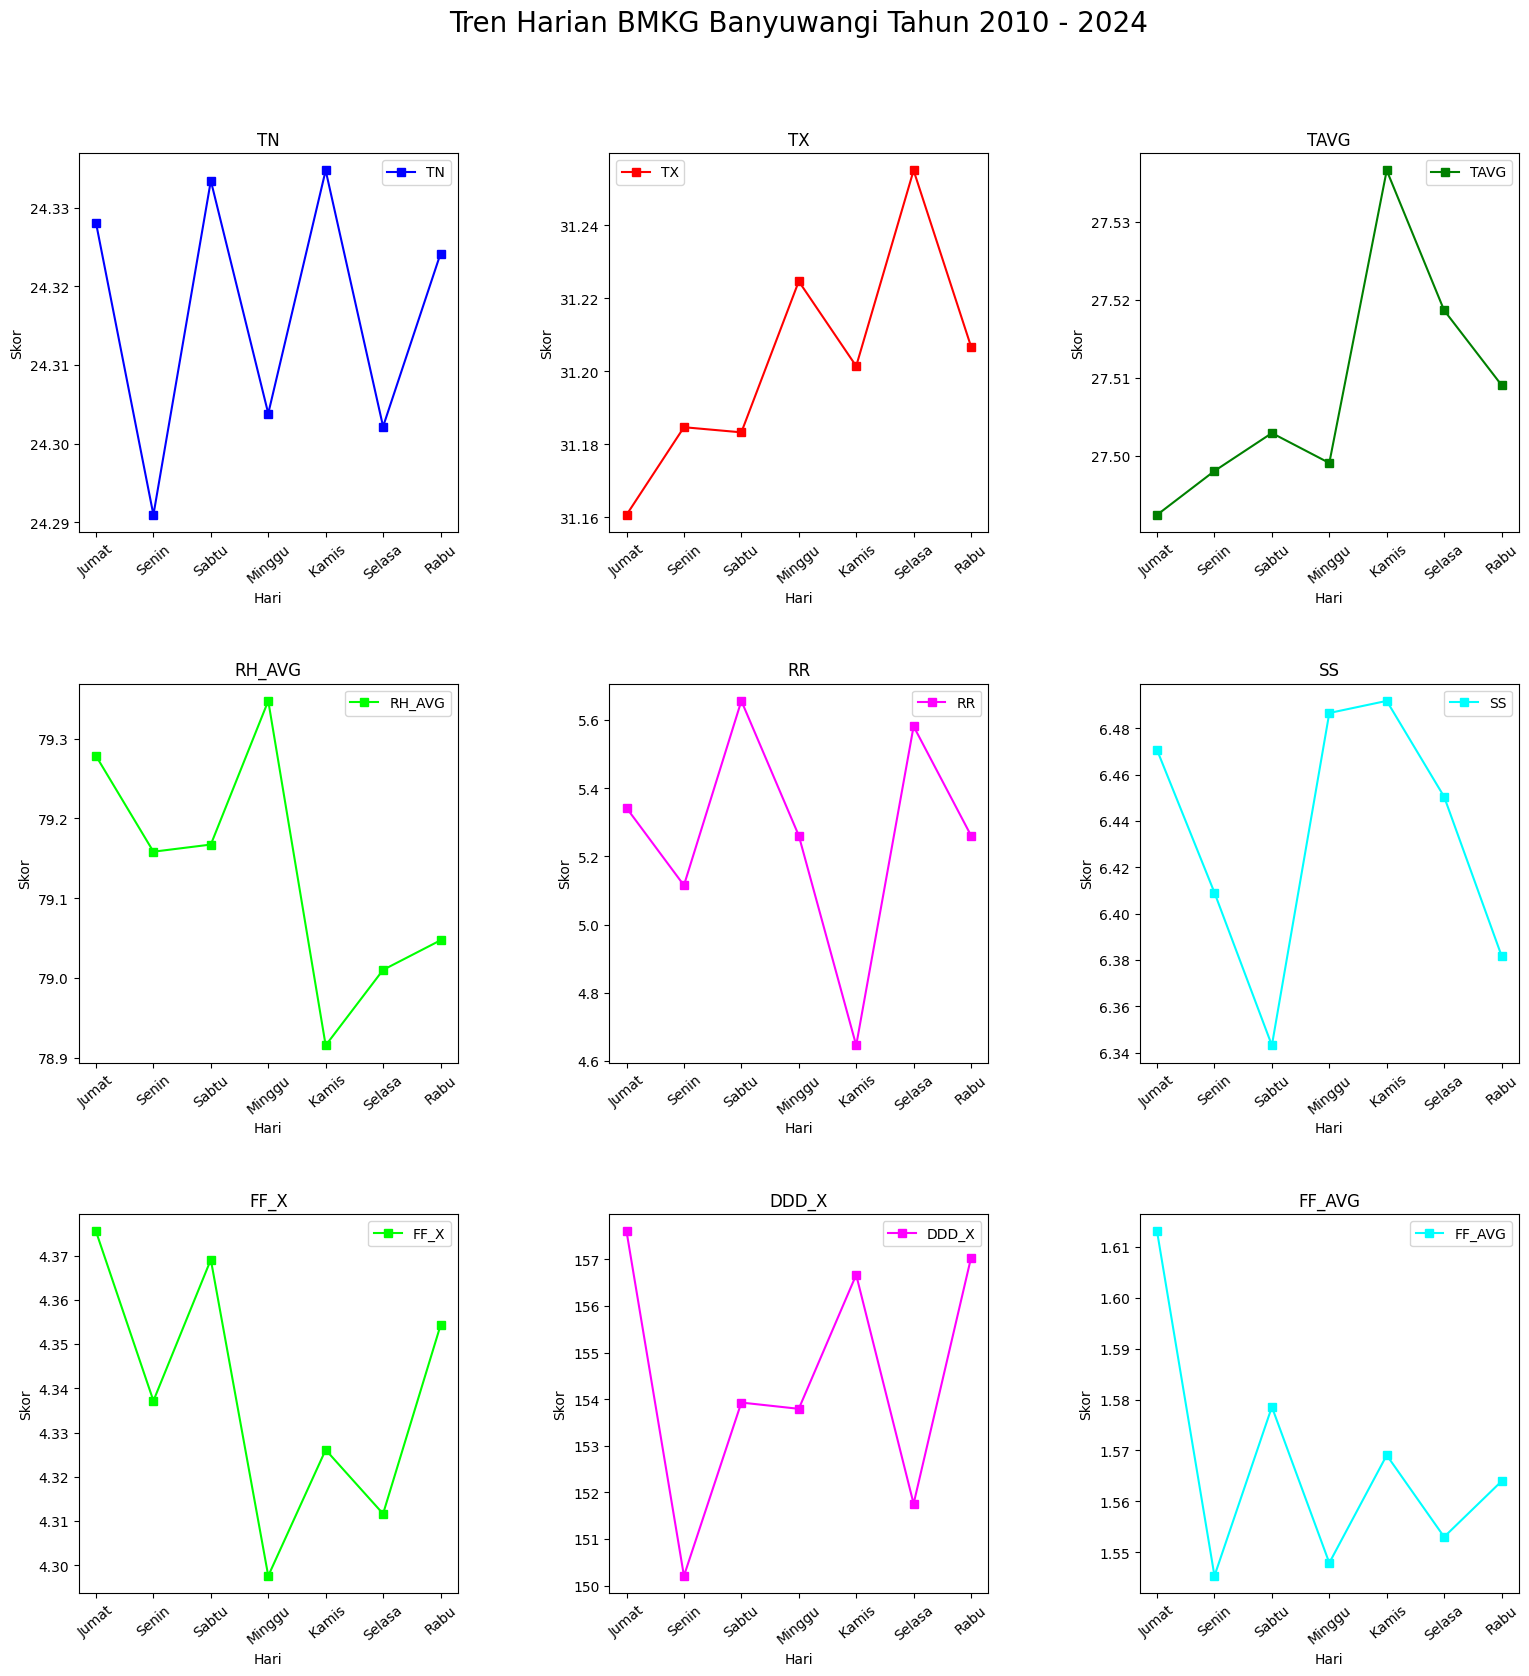

In [30]:
fig = plt.subplots(3, 3, figsize=(18,18))
plt.subplots_adjust(left=0.1 , bottom=0.1, right=0.9, top=0.9, wspace = 0.4, hspace = 0.4)
plt.subplot(3, 3, 1)
abyw.groupby('Hari')['TN'].mean().plot(marker = 's', legend = True, color = 'blue')
plt.xticks([0, 1, 2, 3, 4, 5, 6],['Jumat', 'Senin', 'Sabtu', 'Minggu', ' Kamis', 'Selasa', 'Rabu'],rotation = 40)
plt.title('TN')
plt.ylabel('Skor')
plt.xlabel('Hari')

plt.subplot(3, 3, 2)
abyw.groupby('Hari')['TX'].mean().plot(marker = 's', legend = True, color = 'red')
plt.xticks([0, 1, 2, 3, 4, 5, 6],['Jumat', 'Senin', 'Sabtu', 'Minggu', ' Kamis', 'Selasa', 'Rabu'],rotation = 40)
plt.title('TX')
plt.ylabel('Skor')
plt.xlabel('Hari')

plt.subplot(3, 3, 3)
abyw.groupby('Hari')['TAVG'].mean().plot(marker = 's', legend = True, color = 'green')
plt.xticks([0, 1, 2, 3, 4, 5, 6],['Jumat', 'Senin', 'Sabtu', 'Minggu', ' Kamis', 'Selasa', 'Rabu'],rotation = 40)
plt.title('TAVG')
plt.ylabel('Skor')
plt.xlabel('Hari')

plt.subplot(3, 3, 4)
abyw.groupby('Hari')['RH_AVG'].mean().plot(marker = 's', legend = True, color = 'lime')
plt.xticks([0, 1, 2, 3, 4, 5, 6],['Jumat', 'Senin', 'Sabtu', 'Minggu', ' Kamis', 'Selasa', 'Rabu'],rotation = 40)
plt.title('RH_AVG')
plt.ylabel('Skor')
plt.xlabel('Hari')

plt.subplot(3, 3, 5)
abyw.groupby('Hari')['RR'].mean().plot(marker = 's', legend = True, color = 'magenta')
plt.xticks([0, 1, 2, 3, 4, 5, 6],['Jumat', 'Senin', 'Sabtu', 'Minggu', ' Kamis', 'Selasa', 'Rabu'],rotation = 40)
plt.title('RR')
plt.ylabel('Skor')
plt.xlabel('Hari')

plt.subplot(3, 3, 6)
abyw.groupby('Hari')['SS'].mean().plot(marker = 's', legend = True, color = 'aqua')
plt.xticks([0, 1, 2, 3, 4, 5, 6],['Jumat', 'Senin', 'Sabtu', 'Minggu', ' Kamis', 'Selasa', 'Rabu'],rotation = 40)
plt.title('SS')
plt.ylabel('Skor')
plt.xlabel('Hari')

plt.subplot(3, 3, 7)
abyw.groupby('Hari')['FF_X'].mean().plot(marker = 's', legend = True, color = 'lime')
plt.xticks([0, 1, 2, 3, 4, 5, 6],['Jumat', 'Senin', 'Sabtu', 'Minggu', ' Kamis', 'Selasa', 'Rabu'],rotation = 40)
plt.title('FF_X')
plt.ylabel('Skor')
plt.xlabel('Hari')

plt.subplot(3, 3, 8)
abyw.groupby('Hari')['DDD_X'].mean().plot(marker = 's', legend = True, color = 'magenta')
plt.xticks([0, 1, 2, 3, 4, 5, 6],['Jumat', 'Senin', 'Sabtu', 'Minggu', ' Kamis', 'Selasa', 'Rabu'],rotation = 40)
plt.title('DDD_X')
plt.ylabel('Skor')
plt.xlabel('Hari')

plt.subplot(3, 3, 9)
abyw.groupby('Hari')['FF_AVG'].mean().plot(marker = 's', legend = True, color = 'aqua')
plt.xticks([0, 1, 2, 3, 4, 5, 6],['Jumat', 'Senin', 'Sabtu', 'Minggu', ' Kamis', 'Selasa', 'Rabu'],rotation = 40)
plt.title('FF_AVG')
plt.ylabel('Skor')
plt.xlabel('Hari')

plt.suptitle("Tren Harian BMKG Banyuwangi Tahun 2010 - 2024",fontsize=20)
plt.show()
#membuat grafik garis untuk setiap variabel polutan berdasarkan hari dalam seminggu, untuk melihat tren harian indikator iklim dari tahun 2010 hingga 2024

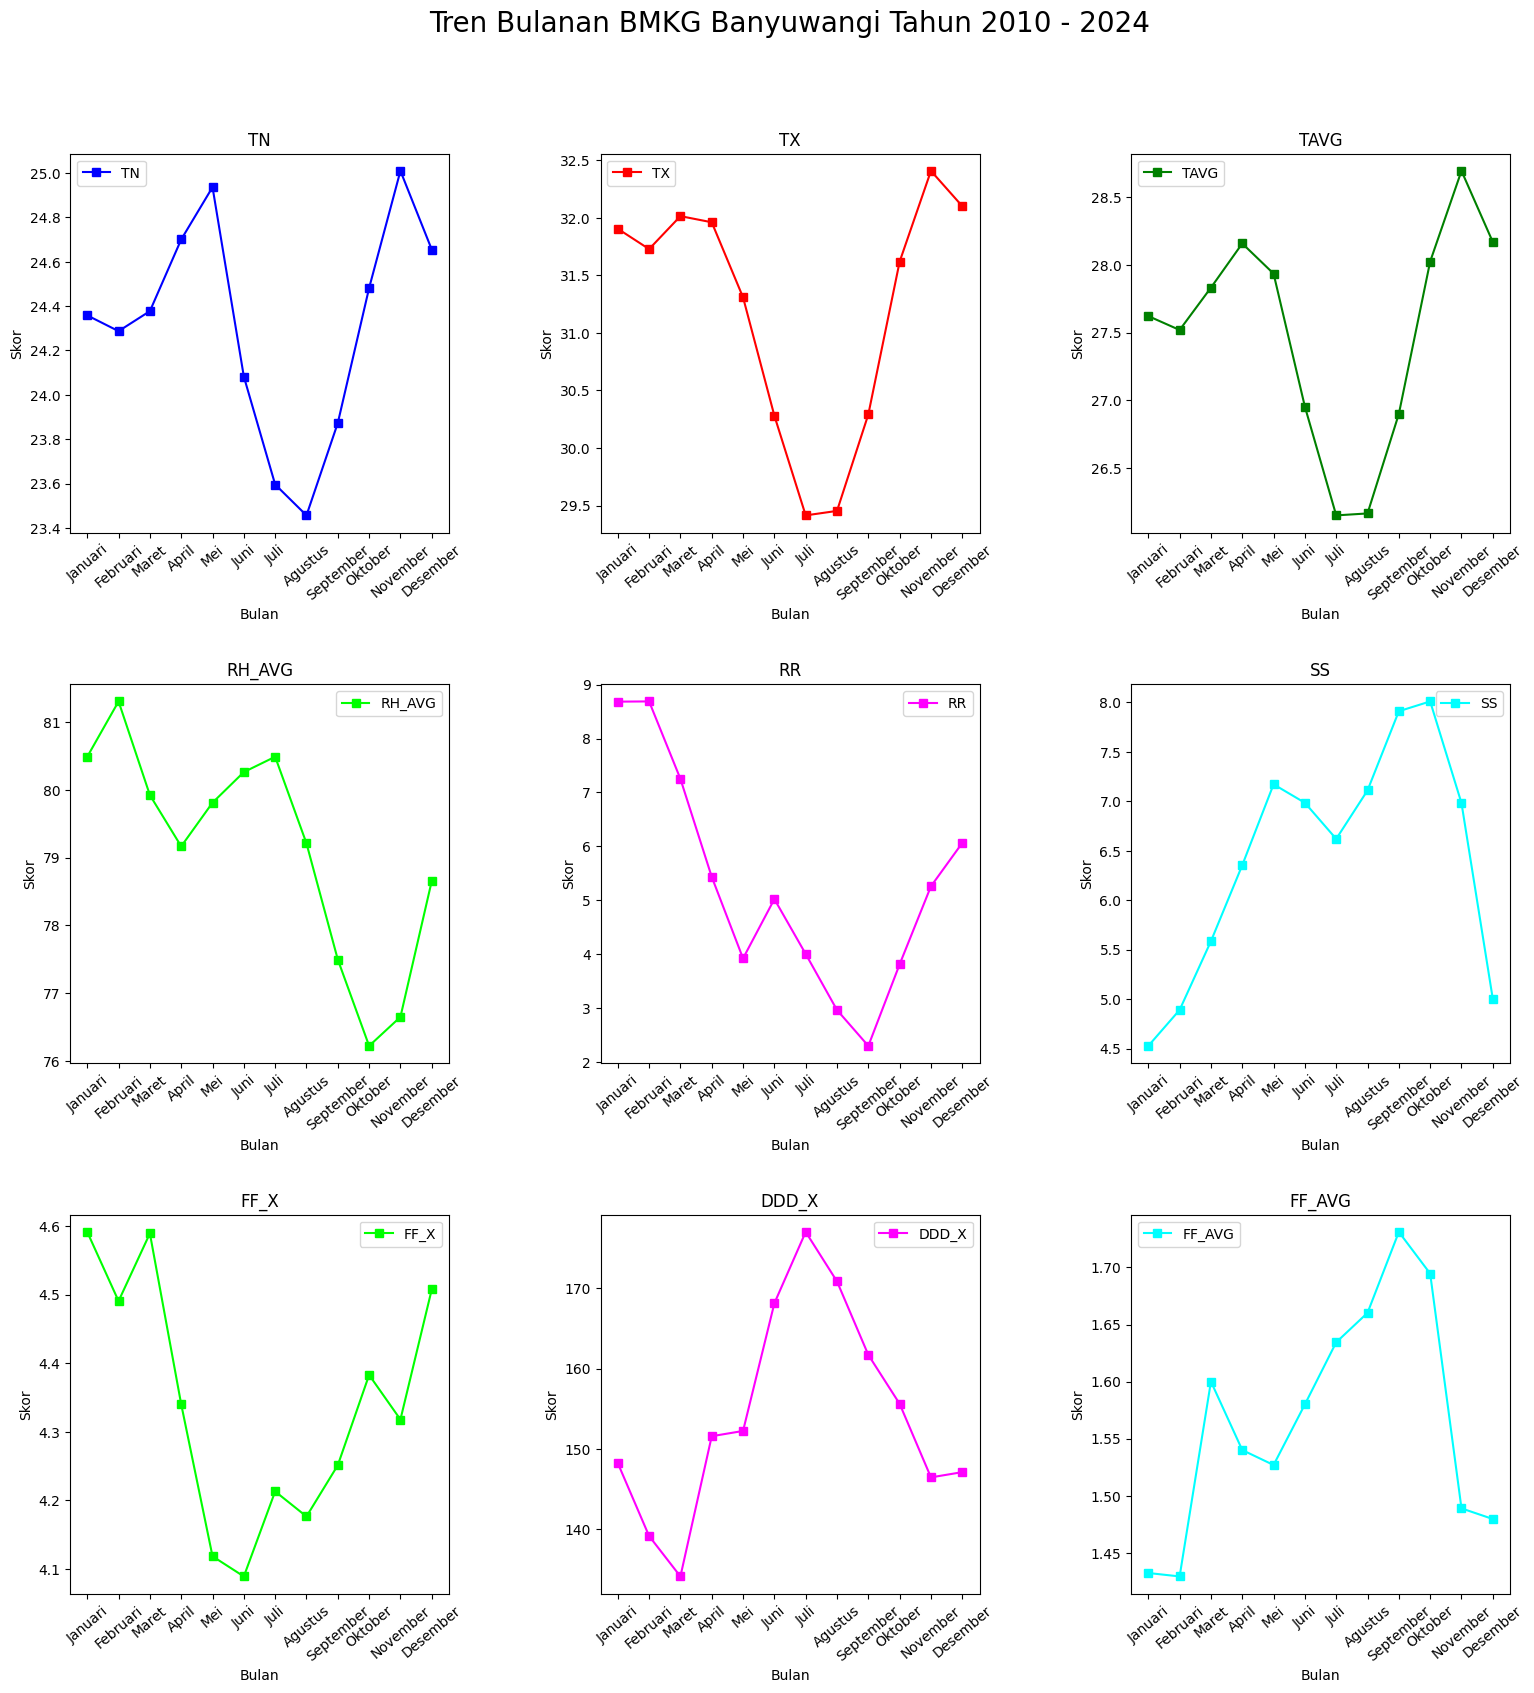

In [28]:
fig = plt.subplots(3, 3, figsize=(18, 18))
plt.subplots_adjust(left=0.1 , bottom=0.1, right=0.9, top=0.9, wspace = 0.4, hspace = 0.4)
plt.subplot(3, 3, 1)
abyw.groupby('Bulan')['TN'].mean().plot(marker = 's', legend = True, color = 'blue')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],rotation = 40)
plt.title('TN')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 2)
abyw.groupby('Bulan')['TX'].mean().plot(marker = 's', legend = True, color = 'red')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],rotation = 40)
plt.title('TX')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 3)
abyw.groupby('Bulan')['TAVG'].mean().plot(marker = 's', legend = True, color = 'green')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],rotation = 40)
plt.title('TAVG')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 4)
abyw.groupby('Bulan')['RH_AVG'].mean().plot(marker = 's', legend = True, color = 'lime')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],rotation = 40)
plt.title('RH_AVG')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 5)
abyw.groupby('Bulan')['RR'].mean().plot(marker = 's', legend = True, color = 'magenta')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],rotation = 40)
plt.title('RR')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 6)
abyw.groupby('Bulan')['SS'].mean().plot(marker = 's', legend = True, color = 'aqua')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],rotation = 40)
plt.title('SS')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 7)
abyw.groupby('Bulan')['FF_X'].mean().plot(marker = 's', legend = True, color = 'lime')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],rotation = 40)
plt.title('FF_X')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 8)
abyw.groupby('Bulan')['DDD_X'].mean().plot(marker = 's', legend = True, color = 'magenta')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],rotation = 40)
plt.title('DDD_X')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.subplot(3, 3, 9)
abyw.groupby('Bulan')['FF_AVG'].mean().plot(marker = 's', legend = True, color = 'aqua')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'],rotation = 40)
plt.title('FF_AVG')
plt.ylabel('Skor')
plt.xlabel('Bulan')

plt.suptitle("Tren Bulanan BMKG Banyuwangi Tahun 2010 - 2024",fontsize=20)
plt.show()
#membuat 6 grafik garis untuk menunjukkan tren rata-rata harian dari setiap polutan udara (PM10, CO, O3, NO2, SO2, dan PM2.5) berdasarkan bulan, menggunakan data ISPU Jakarta tahun 2018–2022

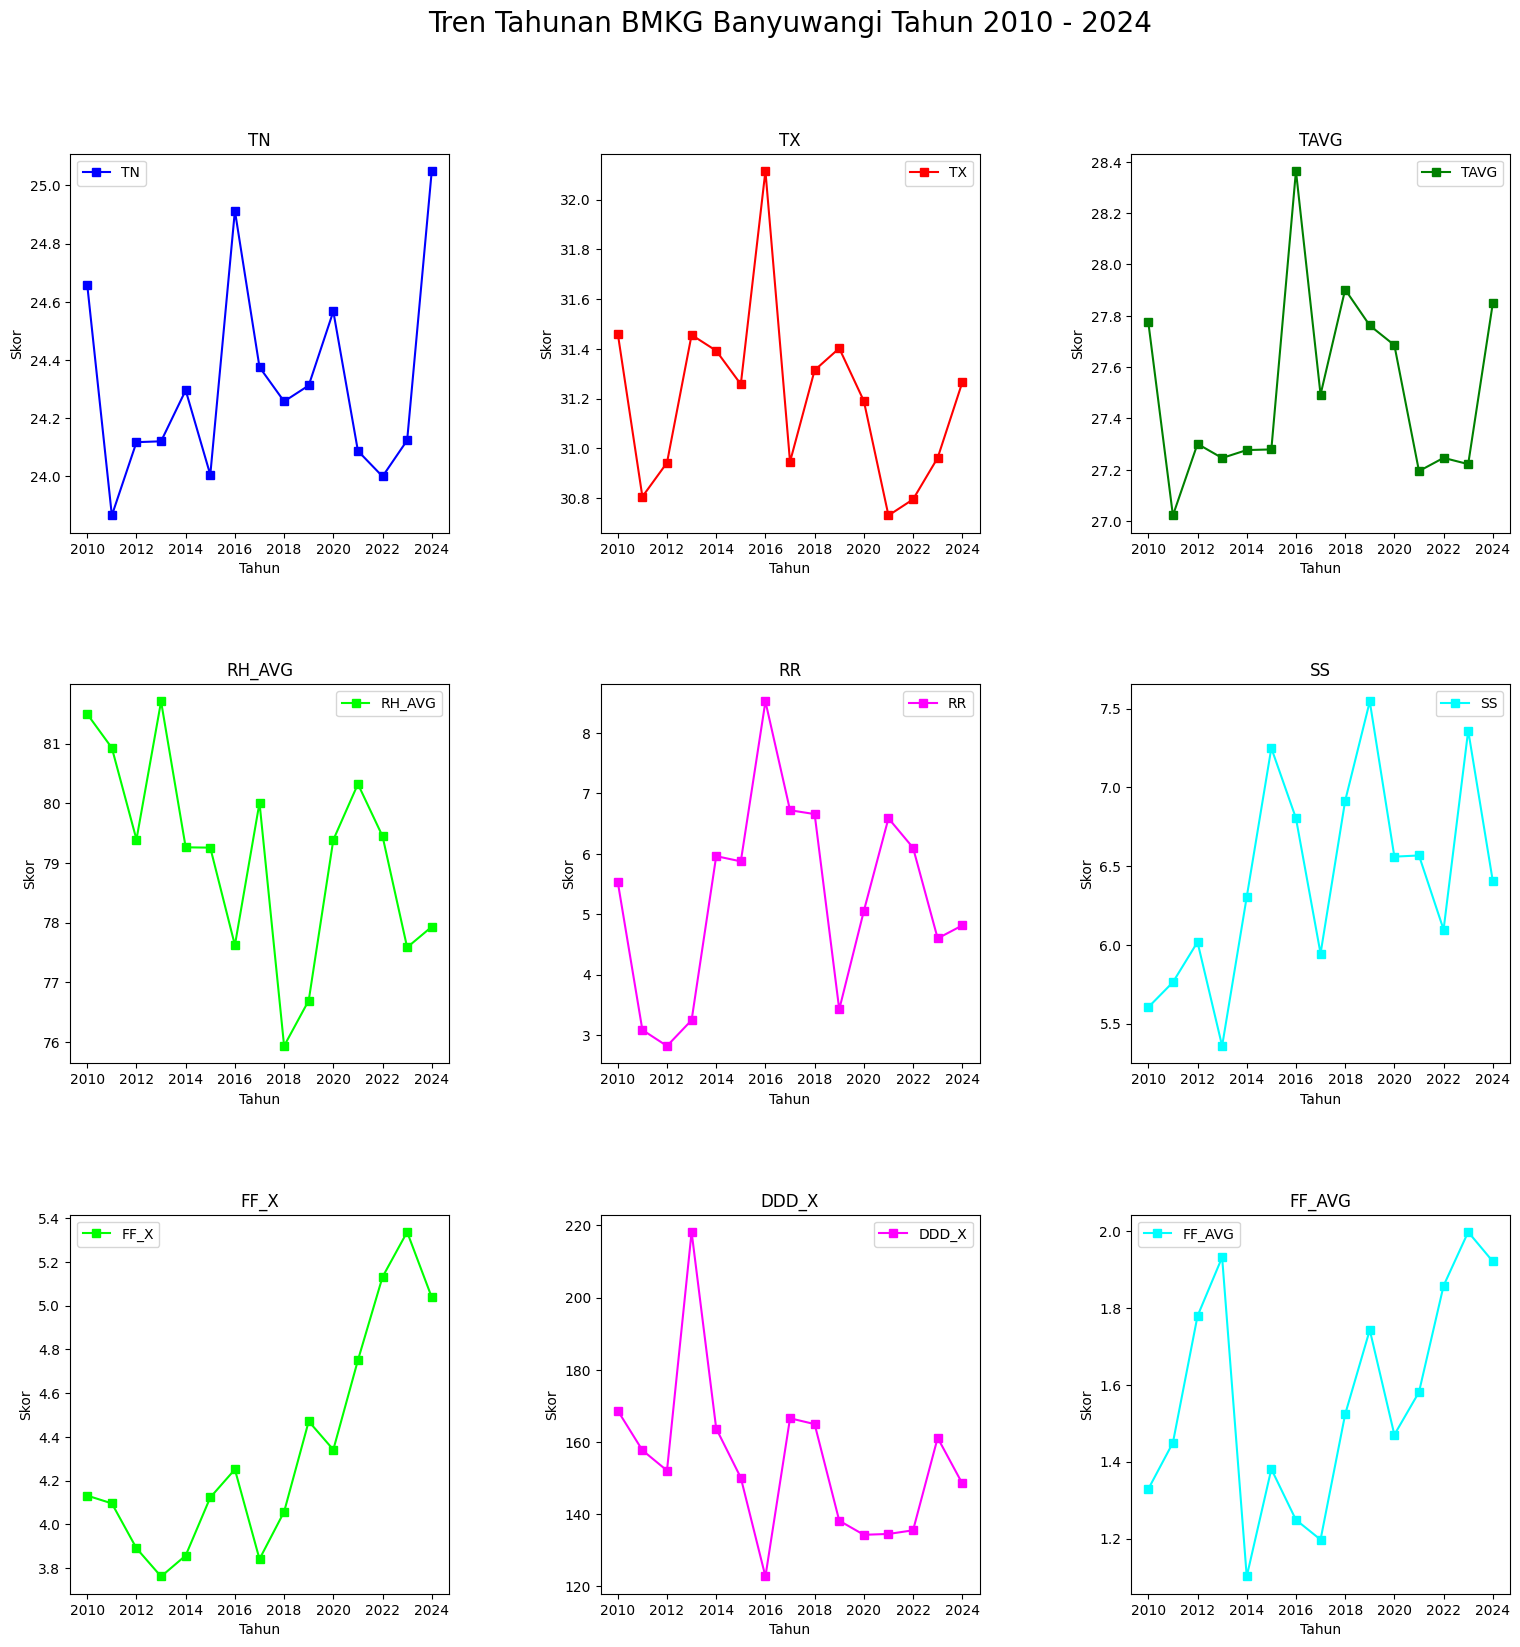

In [31]:
fig = plt.subplots(3, 3, figsize=(18,18))
plt.subplots_adjust(left=0.1 , bottom=0.1, right=0.9, top=0.9, wspace = 0.4, hspace = 0.4)
plt.subplot(3, 3, 1)
abyw.groupby('Tahun')['TN'].mean().plot(marker = 's', legend = True, color = 'blue')
plt.title('TN')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 2)
abyw.groupby('Tahun')['TX'].mean().plot(marker = 's', legend = True, color = 'red')
plt.title('TX')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 3)
abyw.groupby('Tahun')['TAVG'].mean().plot(marker = 's', legend = True, color = 'green')
plt.title('TAVG')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 4)
abyw.groupby('Tahun')['RH_AVG'].mean().plot(marker = 's', legend = True, color = 'lime')
plt.title('RH_AVG')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 5)
abyw.groupby('Tahun')['RR'].mean().plot(marker = 's', legend = True, color = 'magenta')
plt.title('RR')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 6)
abyw.groupby('Tahun')['SS'].mean().plot(marker = 's', legend = True, color = 'aqua')
plt.title('SS')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 7)
abyw.groupby('Tahun')['FF_X'].mean().plot(marker = 's', legend = True, color = 'lime')
plt.title('FF_X')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 8)
abyw.groupby('Tahun')['DDD_X'].mean().plot(marker = 's', legend = True, color = 'magenta')
plt.title('DDD_X')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.subplot(3, 3, 9)
abyw.groupby('Tahun')['FF_AVG'].mean().plot(marker = 's', legend = True, color = 'aqua')
plt.title('FF_AVG')
plt.ylabel('Skor')
plt.xlabel('Tahun')

plt.suptitle("Tren Tahunan BMKG Banyuwangi Tahun 2010 - 2024",fontsize=20)
plt.show()
#membuat grafik garis untuk setiap variabel polutan berdasarkan hari dalam seminggu, untuk melihat tren harian indikator iklim dari tahun 2010 hingga 2024

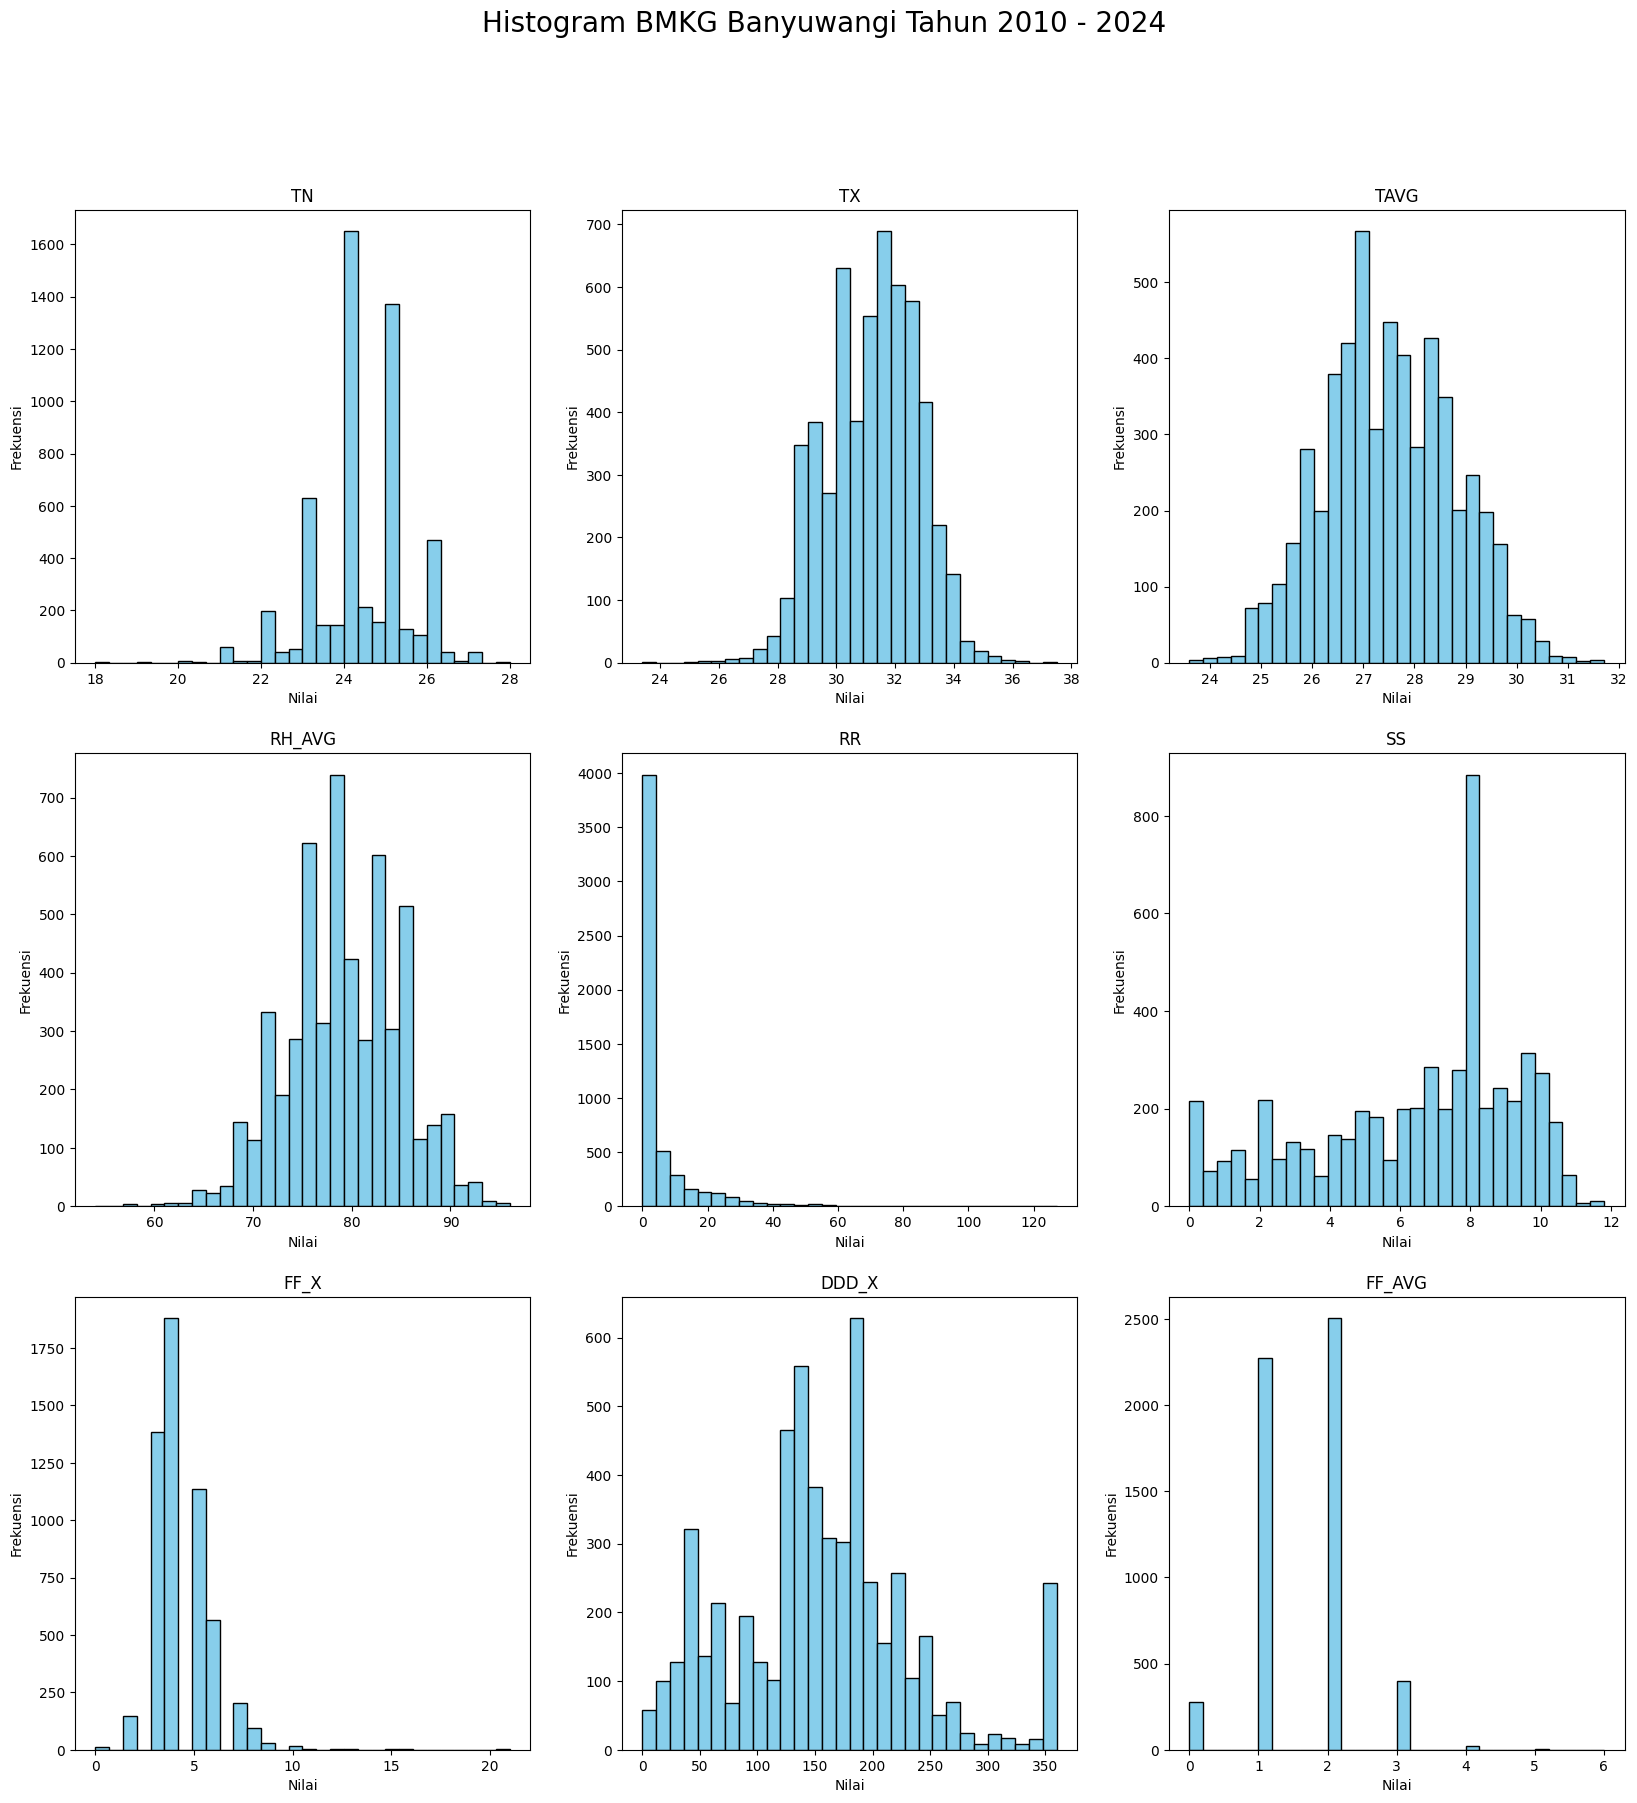

In [29]:
#membuat 6 buah histogram dalam satu tampilan (figure) menggunakan matplotlib untuk memvisualisasikan data polutan udara dari DataFrame abyw dan ispu4
fig = plt.subplots(3, 3, figsize=(20,20))
plt.subplot(3, 3, 1)
plt.hist(abyw['TN'], bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title('TN')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')
#Simetris

plt.subplot(3, 3, 2)
plt.hist(abyw['TX'], bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title('TX')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')
#Miring ke kiri

plt.subplot(3, 3, 3)
plt.hist(abyw['TAVG'], bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title('TAVG')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')
#Miring ke kiri

plt.subplot(3, 3, 4)
plt.hist(abyw['RH_AVG'], bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title('RH_AVG')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')
#Miring ke kiri

plt.subplot(3, 3, 5)
plt.hist(abyw['RR'], bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title('RR')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')
#Bimodal

plt.subplot(3, 3, 6)
plt.hist(abyw['SS'], bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title('SS')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')
#simetris

plt.subplot(3, 3, 7)
plt.hist(abyw['FF_X'], bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title('FF_X')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')
#Miring ke kiri

plt.subplot(3, 3, 8)
plt.hist(abyw['DDD_X'], bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title('DDD_X')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')
#Miring ke kiri

plt.subplot(3, 3, 9)
plt.hist(abyw['FF_AVG'], bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title('FF_AVG')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')
#Bimodal

plt.suptitle("Histogram BMKG Banyuwangi Tahun 2010 - 2024",fontsize=20)
plt.show()
#Kode ini membuat 6 histogram untuk setiap variabel polutan udara (TN, TX, TAVG, RH_AVG, RR, SS, FF_X, DDD_X, FF_AVG) berdasarkan data dari DataFrame abyw. Histogram ini digunakan untuk memvisualisasikan distribusi nilai-nilai polutan tersebut.

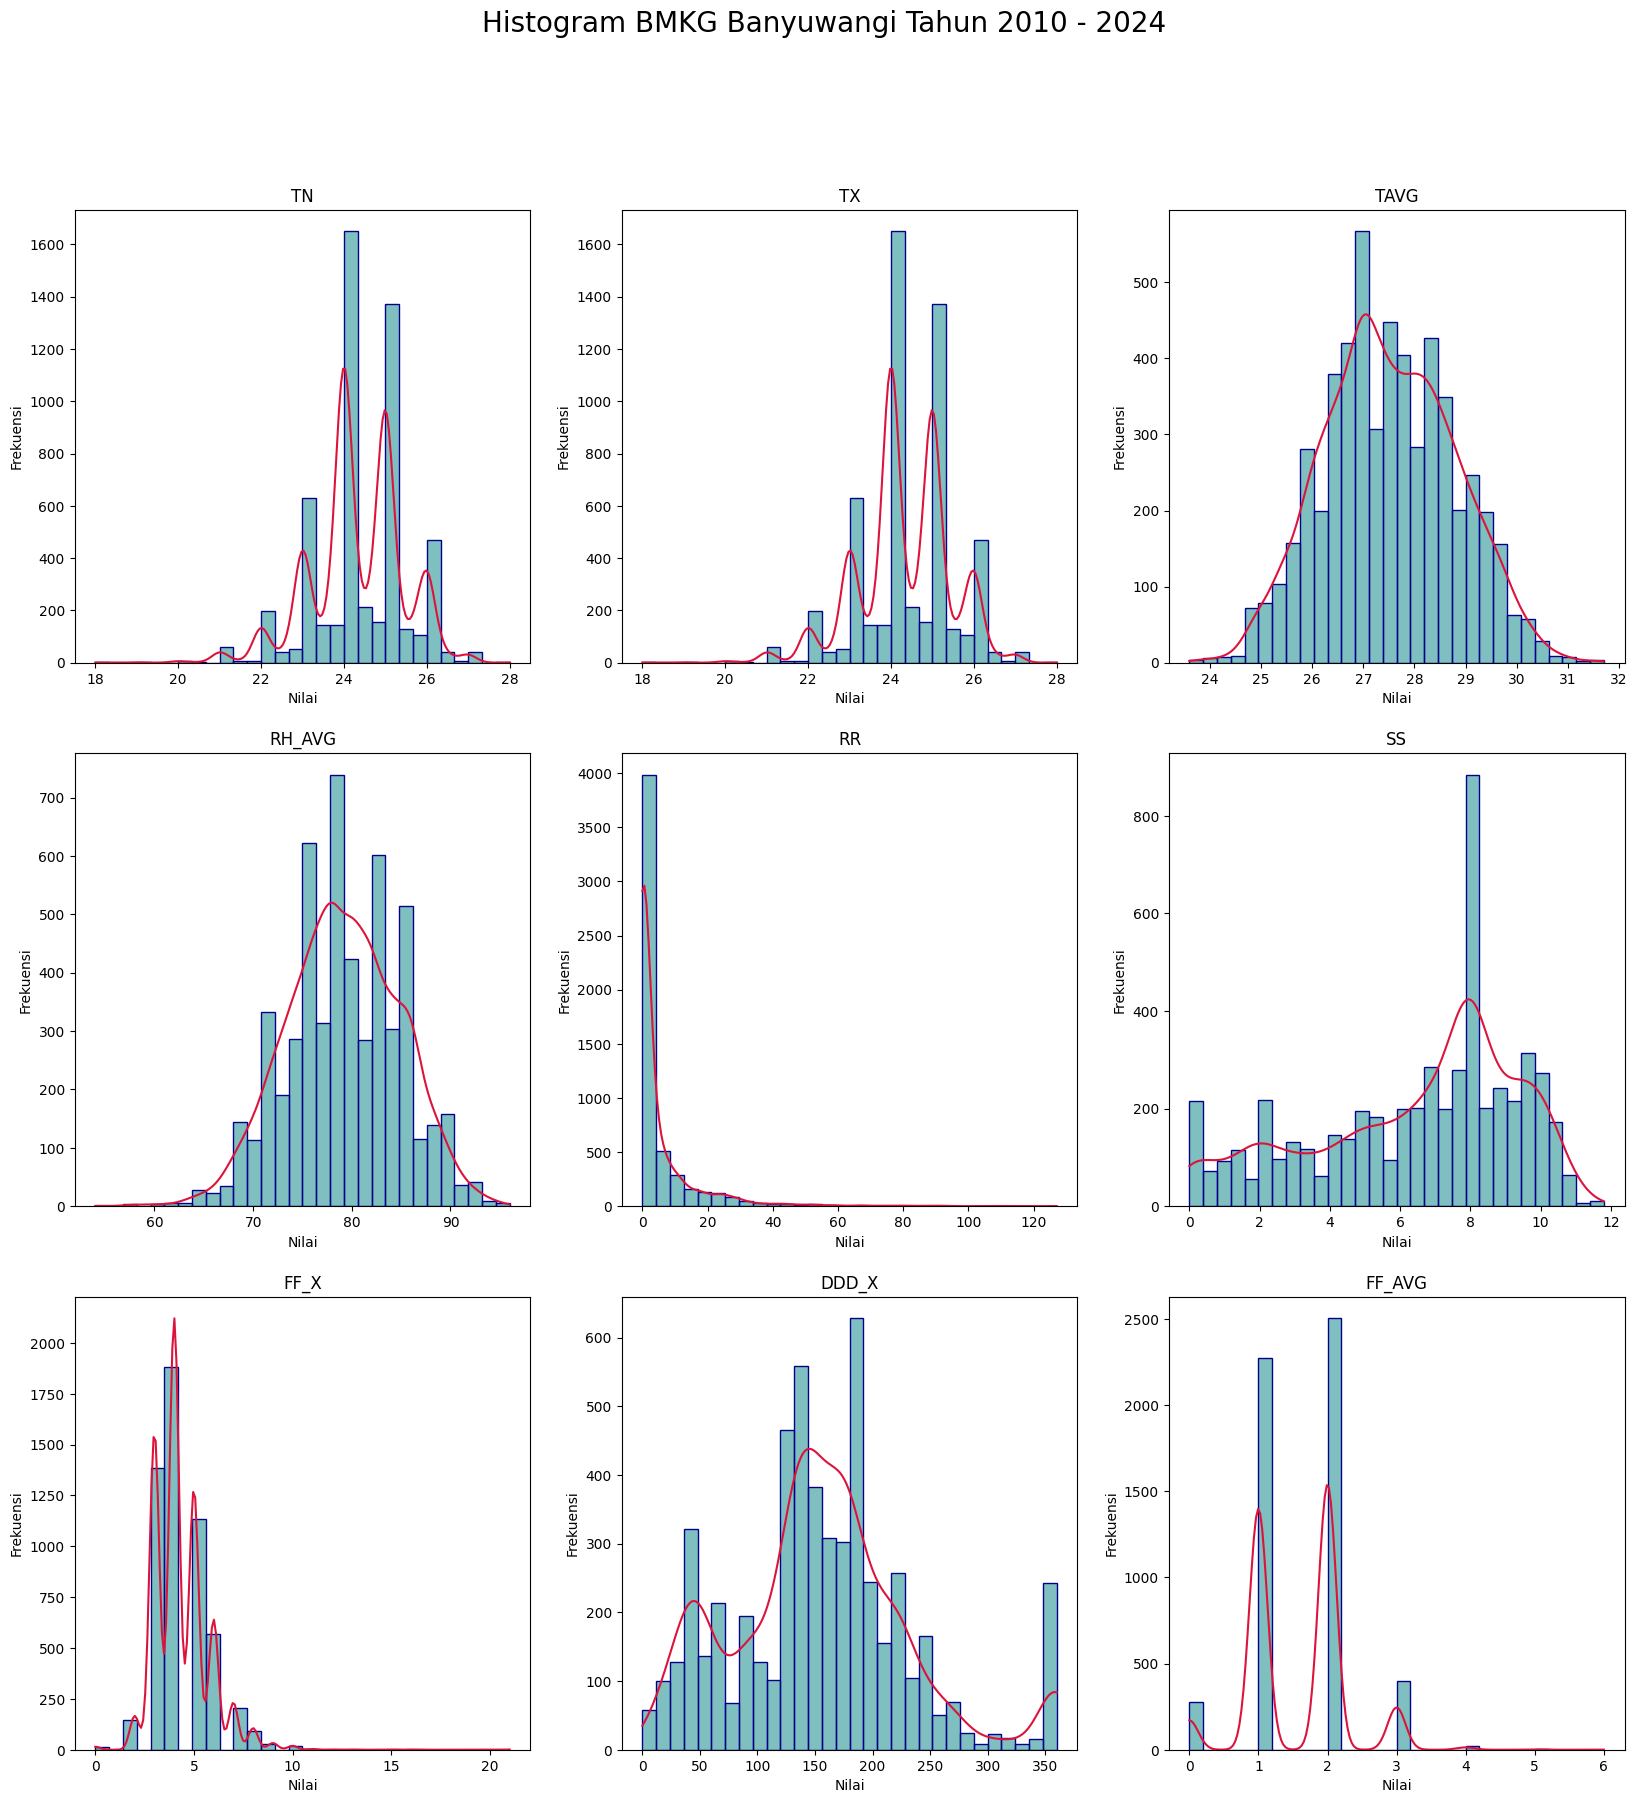

In [33]:
#Menampilkan 6 buah histogram menggunakan Seaborn dengan tambahan kurva KDE (Kernel Density Estimation) untuk menunjukkan bentuk distribusi data polutan udara
fig = plt.subplots(3, 3, figsize=(20,20))
plt.subplot(3, 3, 1)
ax = sns.histplot(abyw['TN'], bins = 30, kde = True, color = 'teal', edgecolor = 'darkblue')
ax.lines[0].set_color('crimson')
plt.title('TN')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')

plt.subplot(3, 3, 2)
ax = sns.histplot(abyw['TN'], bins = 30, kde = True, color = 'teal', edgecolor = 'darkblue')
ax.lines[0].set_color('crimson')
plt.title('TX')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')

plt.subplot(3, 3, 3)
ax = sns.histplot(abyw['TAVG'], bins = 30, kde = True, color = 'teal', edgecolor = 'darkblue')
ax.lines[0].set_color('crimson')
plt.title('TAVG')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')

plt.subplot(3, 3, 4)
ax = sns.histplot(abyw['RH_AVG'], bins = 30, kde = True, color = 'teal', edgecolor = 'darkblue')
ax.lines[0].set_color('crimson')
plt.title('RH_AVG')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')

plt.subplot(3, 3, 5)
ax = sns.histplot(abyw['RR'], bins = 30, kde = True, color = 'teal', edgecolor = 'darkblue')
ax.lines[0].set_color('crimson')
plt.title('RR')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')

plt.subplot(3, 3, 6)
ax = sns.histplot(abyw['SS'], bins = 30, kde = True, color = 'teal', edgecolor = 'darkblue')
ax.lines[0].set_color('crimson')
plt.title('SS')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')

plt.subplot(3, 3, 7)
ax = sns.histplot(abyw['FF_X'], bins = 30, kde = True, color = 'teal', edgecolor = 'darkblue')
ax.lines[0].set_color('crimson')
plt.title('FF_X')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')

plt.subplot(3, 3, 8)
ax = sns.histplot(abyw['DDD_X'], bins = 30, kde = True, color = 'teal', edgecolor = 'darkblue')
ax.lines[0].set_color('crimson')
plt.title('DDD_X')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')

plt.subplot(3, 3, 9)
ax = sns.histplot(abyw['FF_AVG'], bins = 30, kde = True, color = 'teal', edgecolor = 'darkblue')
ax.lines[0].set_color('crimson')
plt.title('FF_AVG')
plt.ylabel('Frekuensi')
plt.xlabel('Nilai')

plt.suptitle("Histogram BMKG Banyuwangi Tahun 2010 - 2024",fontsize=20)
plt.show()

#Menggunakan **Seaborn** (sns.histplot) yang lebih estetis dan bisa langsung menambahkan kurva KDE.